# CSCN8020 — Assignment 2: Q-Learning on the Taxi Gymnasium Environment

| | |
|---|---|
| **Student Name** | Sumanth Reddy Konannagari |
| **Student ID** | 9040660 |
| **Course** | CSCN8020 — Reinforcement Learning |


---

## Table of Contents

1. [Introduction to the Taxi Problem](#1-introduction-to-the-taxi-problem)
2. [Q-Learning Theory](#2-q-learning-theory)
3. [Environment Setup & Verification](#3-environment-setup--verification)
4. [Object-Oriented Architecture](#4-object-oriented-architecture)
5. [Task 1 — Q-Learning Implementation & Baseline Training](#5-task-1--q-learning-implementation--baseline-training)
6. [Task 2 — Training Metrics & Plots](#6-task-2--training-metrics--plots)
7. [Task 3 — Hyperparameter Experiments](#7-task-3--hyperparameter-experiments)
8. [Task 4 — Best Combination Experiment](#8-task-4--best-combination-experiment)
9. [Five Talking Points](#9-five-talking-points)
10. [Final Conclusion](#10-final-conclusion)

---


## 1. Introduction to the Taxi Problem

### What is the Problem?

Picture a small 5×5 city grid. A taxi is parked somewhere on it. A passenger is waiting at one of four coloured spots — **Red, Green, Yellow, or Blue**. The passenger needs to reach one of those same four locations.

The taxi must learn — completely on its own, with no instructions — to:

1. Drive to the passenger's location
2. Pick up the passenger
3. Drive to the correct destination
4. Drop off the passenger

There is no map. No GPS. No pre-programmed routes. The taxi learns purely by trying things, getting feedback (rewards or penalties), and slowly figuring out what works.

---

### Observation Space — What the Taxi Sees

Every situation the taxi can be in is represented by a single number called the **state**. There are **500 possible states** because the environment simultaneously tracks:

| What | Options | Count |
|---|---|---|
| Taxi position on the 5×5 grid | Any of 25 cells | 25 |
| Passenger location | Red, Green, Yellow, Blue, or **In Taxi** | 5 |
| Destination | Red, Green, Yellow, Blue | 4 |

**Total states = 25 × 5 × 4 = 500**

The state is encoded as a single integer using this exact formula:

$$\text{state} = \big((\text{taxi\_row} \times 5 + \text{taxi\_col})\times 5 + \text{passenger\_loc}\big) \times 4 + \text{destination}$$

| Code | Passenger Location |
|---|---|
| 0 | Red |
| 1 | Green |
| 2 | Yellow |
| 3 | Blue |
| 4 | In Taxi |

| Code | Destination |
|---|---|
| 0 | Red |
| 1 | Green |
| 2 | Yellow |
| 3 | Blue |

---

### Action Space — What the Taxi Can Do

At every step, the taxi picks exactly one of 6 actions:

| Action Code | Action | Effect |
|---|---|---|
| 0 | Move South | Move one cell down |
| 1 | Move North | Move one cell up |
| 2 | Move East | Move one cell right |
| 3 | Move West | Move one cell left |
| 4 | Pickup | Pick up the passenger |
| 5 | Dropoff | Drop off the passenger |

---

### Reward Structure — How the Taxi Learns

The taxi gets feedback after every single action:

| Event | Reward | Why |
|---|---|---|
| Every step taken | **−1** | Encourages the taxi to be fast |
| Correct delivery | **+20** | Rewards the goal |
| Illegal pickup or dropoff | **−10** | Penalises wrong actions |

The cumulative reward over an episode tells us how well the taxi did. A high reward means it was fast and accurate. A deeply negative reward means it wandered randomly or made many illegal moves.

---


## 2. Q-Learning Theory

### What is Reinforcement Learning?

Reinforcement Learning (RL) is a style of machine learning where an **agent** learns by **interacting with an environment** and receiving **feedback in the form of rewards**.

It is fundamentally different from:
- **Supervised learning** — which needs labelled input-output pairs prepared in advance
- **Unsupervised learning** — which finds patterns in data without any feedback

In RL, there is no dataset and no teacher. The agent generates its own experience by taking actions, observing what happens, and adjusting its behaviour based on the rewards it receives.

---

### What is Q-Learning?

Q-Learning is a specific RL algorithm. The letter **"Q"** stands for **Quality** — the quality of taking a particular action in a particular state.

Q-Learning builds and maintains a **Q-table**: a grid where:
- **Each row** = one of the 500 possible states
- **Each column** = one of the 6 possible actions
- **Each cell value** = the agent's estimate of total future reward for that action in that state

At the start, every cell is 0 (the agent knows nothing). Over thousands of episodes, the values in the table become more and more accurate, and the taxi gets better and better at its job.

**Q-Learning is off-policy**: it learns the *optimal* policy (always pick the best action) even while it is *behaving* with an exploratory policy (sometimes picking random actions). This is what makes it different from SARSA, which is on-policy.

---

### The Q-Learning Update Equation

After every action the agent takes, it updates the Q-table using this equation (Sutton & Barto, 2018 — Chapter 6.5):

$$\boxed{Q(s,a) \leftarrow Q(s,a) + \alpha\Big[R + \gamma \cdot \max_{a'}Q(s',a') - Q(s,a)\Big]}$$

**Breaking it down in plain English:**

| Symbol | Full Name | Plain Meaning |
|---|---|---|
| $Q(s, a)$ | Current Q-value | Our current best guess of how good action $a$ is in state $s$ |
| $\alpha$ | Learning rate | How big a step we take when updating — too high = unstable, too low = slow |
| $R$ | Reward | The reward we actually received after taking action $a$ |
| $\gamma$ | Discount factor | How much we value future rewards (0 = ignore future, 1 = fully value it) |
| $\max_{a'} Q(s',a')$ | Best future value | The highest Q-value we can get from the next state $s'$ |
| $s'$ | Next state | The state the environment moved us to after taking action $a$ |
| $R + \gamma \cdot \max_{a'} Q(s',a')$ | TD Target | What we now think the true value should be |
| $\text{TD Target} - Q(s,a)$ | TD Error | How wrong our current estimate was |

**In one sentence:** After each action, shift our estimate a little bit ($\alpha$) toward what we now believe the true value is.

---

### Exploration vs Exploitation — Epsilon-Greedy

The agent faces a trade-off every single step:
- **Exploit**: Use the Q-table to pick the best known action → safe but may miss better paths
- **Explore**: Pick a random action → risky but may discover better paths

The **epsilon-greedy** strategy handles this:

$$\text{Action} = \begin{cases} \text{random action} & \text{with probability } \epsilon \\ \arg\max_a Q(s,a) & \text{with probability } 1-\epsilon \end{cases}$$

With $\epsilon = 0.1$: the agent explores 10% of the time and exploits 90% of the time.

---

### Baseline Hyperparameters

| Hyperparameter | Symbol | Value | Meaning |
|---|---|---|---|
| Learning Rate | $\alpha$ | **0.1** | 10% of the TD error is used to update Q each step |
| Exploration Factor | $\epsilon$ | **0.1** | 10% of actions are random (explore) |
| Discount Factor | $\gamma$ | **0.9** | Future rewards are worth 90% of their face value |

---

### Q-Learning Pseudocode (Sutton & Barto, 2018 — Chapter 6.5)

```
Initialize Q(s, a) = 0,  for all s ∈ S,  a ∈ A
Set Q(terminal-state, ·) = 0

For each episode:
    Initialize state  S

    For each step of episode:
        Choose action A from state S  using ε-greedy policy derived from Q
        Take action A → observe reward R and next state S'
        Q(S, A) ← Q(S, A) + α [ R + γ · max_a Q(S', a)  −  Q(S, A) ]
        S ← S'
    Until S is terminal (episode ends)
```

Every single line of this pseudocode maps directly to Python code in this notebook — shown in Task 1.

---


## 3. Environment Setup & Verification

### Step 1 — Import all required libraries


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# Run this cell first. Every library used in this notebook is imported here.
# ─────────────────────────────────────────────────────────────────────────────

import gymnasium as gym               # Provides the Taxi-v4 environment
import numpy as np                    # Q-table storage and numerical operations
import matplotlib.pyplot as plt       # All plots and charts
import matplotlib.patches as mpatches # Custom legend patches for plots
import pandas as pd                   # Metrics tables
import logging                        # Structured log file generation
import warnings                       # Suppress harmless version warnings

warnings.filterwarnings('ignore')

# Fix random seed for reproducibility — same results every run
np.random.seed(42)

# ── Global plot style ─────────────────────────────────────────────────────────
# Applied once here so every plot in the notebook looks consistent
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#f7f9fc',
    'axes.grid'         : True,
    'grid.alpha'        : 0.4,
    'grid.linestyle'    : '--',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 12,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 10,
    'legend.framealpha' : 0.9,
    'figure.dpi'        : 130,
})

print("✓ All imports successful")
print(f"  gymnasium  : {gym.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  matplotlib : {plt.matplotlib.__version__}")
print(f"  pandas     : {pd.__version__}")


✓ All imports successful
  gymnasium  : 1.3.0
  numpy      : 2.4.4
  matplotlib : 3.10.8
  pandas     : 3.0.2


### Step 2 — Create and verify the Taxi-v4 environment

Before training, we confirm the environment matches the assignment specification: 500 states, 6 actions, and the correct state decoding formula.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# ENVIRONMENT VERIFICATION
# Creates a temporary environment, checks its structure, and decodes
# a sample state to confirm the state encoding formula is correct.
# ─────────────────────────────────────────────────────────────────────────────

env_check = gym.make('Taxi-v4')
obs, _ = env_check.reset(seed=42)

# ── Verify structure ──────────────────────────────────────────────────────────
print("=" * 55)
print("  Taxi-v4 Environment — Structure Verification")
print("=" * 55)
print(f"  Observation space (states)  : {env_check.observation_space}")
print(f"  Action space (actions)      : {env_check.action_space}")
print(f"  Total states                : {env_check.observation_space.n}")
print(f"  Total actions               : {env_check.action_space.n}")
print(f"  Sample encoded state        : {obs}")

# ── Decode the sample state using the assignment formula ──────────────────────
# Formula: state = ((taxi_row * 5 + taxi_col) * 5 + passenger_loc) * 4 + destination
# We reverse the formula to decode:
dest         = obs % 4
passenger    = (obs // 4) % 5
taxi_col     = (obs // 20) % 5
taxi_row     = obs // 100

PASSENGER_NAMES    = ['Red', 'Green', 'Yellow', 'Blue', 'In Taxi']
DESTINATION_NAMES  = ['Red', 'Green', 'Yellow', 'Blue']

print("=" * 55)
print(f"  Decoded state {obs}:")
print(f"    Taxi position     : row {taxi_row}, col {taxi_col}")
print(f"    Passenger at      : {PASSENGER_NAMES[passenger]}")
print(f"    Destination       : {DESTINATION_NAMES[dest]}")
print("=" * 55)

env_check.close()
print("\n✓ Environment verified — matches assignment specification")


  Taxi-v4 Environment — Structure Verification
  Observation space (states)  : Discrete(500)
  Action space (actions)      : Discrete(6)
  Total states                : 500
  Total actions               : 6
  Sample encoded state        : 386
  Decoded state 386:
    Taxi position     : row 3, col 4
    Passenger at      : Green
    Destination       : Yellow

✓ Environment verified — matches assignment specification


## 4. Object-Oriented Architecture

The entire solution is split into **six classes**, each with one clear job. No core logic lives outside these classes.

| Class | Job |
|---|---|
| `TaxiEnvironmentManager` | Creates, resets, steps through, and closes the Taxi-v4 environment |
| `QLearningAgent` | Owns the Q-table; selects actions; applies the Q-update rule |
| `MetricsLogger` | Records rewards and steps per episode; writes the training log file |
| `QLearningTrainer` | Runs the full episode loop; connects agent, environment, and logger |
| `PlotManager` | Generates all plots (all titles, axis labels, legends, smoothing) |
| `ExperimentRunner` | Runs all 7 experiments in sequence; stores and compares results |

---


### Class 1 — `TaxiEnvironmentManager`

**Job:** All contact with the Gymnasium environment goes through this class. No other class calls `gym.make` or `env.step` directly.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASS 1: TaxiEnvironmentManager
# Single responsibility: own and manage the Gymnasium Taxi-v4 environment.
# All env interaction (reset, step, close) is centralised here.
# ─────────────────────────────────────────────────────────────────────────────

class TaxiEnvironmentManager:
    """
    Wraps gymnasium Taxi-v4.
    Provides three clean methods: reset(), step(), close().
    No other class touches the environment object directly.
    """

    def __init__(self, seed: int = 42):
        self.env      = gym.make('Taxi-v4')   # Create the environment
        self.seed     = seed
        self.n_states  = self.env.observation_space.n   # 500
        self.n_actions = self.env.action_space.n        # 6

    def reset(self) -> int:
        """
        Reset the environment to a fresh starting state.
        Returns the initial state as an integer (0–499).
        After the first reset, seed is cleared so episodes start at different states.
        """
        obs, _ = self.env.reset(seed=self.seed)
        self.seed = None          # Remove fixed seed — episodes must vary naturally
        return int(obs)

    def step(self, action: int) -> tuple:
        """
        Apply one action in the environment.
        Returns: (next_state, reward, done)
          - next_state : integer 0–499
          - reward     : float (-1, +20, or -10)
          - done       : True when episode ends (delivered or max steps reached)
        """
        obs, reward, terminated, truncated, _ = self.env.step(action)
        done = terminated or truncated    # Episode ends on either condition
        return int(obs), float(reward), bool(done)

    def close(self):
        """Release environment resources after training is complete."""
        self.env.close()


print("✓ TaxiEnvironmentManager defined")
print(f"  States  : 500   Actions : 6")


✓ TaxiEnvironmentManager defined
  States  : 500   Actions : 6


### Class 2 — `QLearningAgent`

**Job:** The brain of the system. Owns the Q-table. Selects actions using epsilon-greedy. Applies the Q-Learning update rule after every step.

This class maps **directly** to the Sutton & Barto (2018) Chapter 6.5 pseudocode:

| Pseudocode Line | Method in this class |
|---|---|
| Initialize Q(s,a) = 0 for all s, a | `__init__` → `np.zeros((500, 6))` |
| Choose A from S using ε-greedy | `select_action(state)` |
| Q(S,A) ← Q(S,A) + α[R + γ·max Q(S',a') − Q(S,A)] | `update(state, action, reward, next_state)` |


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASS 2: QLearningAgent
# Single responsibility: own Q-table, select actions, apply Q-update rule.
# This is the "brain" — all learning logic lives here.
# ─────────────────────────────────────────────────────────────────────────────

class QLearningAgent:
    """
    Implements Q-Learning as described in Sutton & Barto (2018) Chapter 6.5.

    Q-table shape: (500 states × 6 actions)
    Each Q[s][a] = estimated total future reward for taking action a in state s.
    All values start at 0 (agent knows nothing at the start).
    """

    def __init__(self, n_states: int, n_actions: int,
                 alpha: float = 0.1, epsilon: float = 0.1, gamma: float = 0.9):

        # ── Sutton & Barto: "Initialize Q(s,a) = 0 for all s ∈ S, a ∈ A(s)" ──
        self.Q = np.zeros((n_states, n_actions))   # 500 × 6 table, all zeros

        # Store hyperparameters as instance variables
        self.alpha     = alpha      # α: learning rate
        self.epsilon   = epsilon    # ε: exploration probability
        self.gamma     = gamma      # γ: discount factor
        self.n_actions = n_actions

    def select_action(self, state: int) -> int:
        """
        Epsilon-greedy action selection.
        Sutton & Barto: "Choose A from S using policy derived from Q (e.g. ε-greedy)"

        Two cases:
          EXPLORE  (prob ε)   → return a uniformly random action (0–5)
          EXPLOIT  (prob 1-ε) → return argmax_a Q[state][a]  (best known action)
        """
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)   # EXPLORE: random
        return int(np.argmax(self.Q[state]))           # EXPLOIT: greedy best

    def update(self, state: int, action: int,
               reward: float, next_state: int) -> None:
        """
        Apply the Q-Learning update rule.
        Sutton & Barto Chapter 6.5:
            Q(S,A) ← Q(S,A) + α [ R + γ · max_a Q(S',a) - Q(S,A) ]

        Step-by-step breakdown:
          current_q   = Q(S, A)                    ← our current estimate
          best_next_q = max_a Q(S', a)             ← best available value in next state
          td_target   = R + γ × best_next_q        ← what we now believe the value should be
          td_error    = td_target − current_q       ← how wrong we were (Bellman error)
          Q(S, A)    += α × td_error               ← nudge our estimate toward the target
        """
        current_q   = self.Q[state, action]
        best_next_q = np.max(self.Q[next_state])            # max_a Q(S', a)
        td_target   = reward + self.gamma * best_next_q     # R + γ · max Q(S',a')
        td_error    = td_target - current_q                 # Bellman error
        self.Q[state, action] += self.alpha * td_error      # Q-table update

    def get_best_action(self, state: int) -> int:
        """Return the greedy best action (no exploration). Used for policy evaluation."""
        return int(np.argmax(self.Q[state]))


print("✓ QLearningAgent defined")
print("  Q-table shape   : (500 states × 6 actions) = 3,000 values")
print("  Initialized to  : 0.0  (agent starts with no knowledge)")


✓ QLearningAgent defined
  Q-table shape   : (500 states × 6 actions) = 3,000 values
  Initialized to  : 0.0  (agent starts with no knowledge)


### Class 3 — `MetricsLogger`

**Job:** Records per-episode metrics (reward, steps) and writes a structured log file using Python's `logging` module with timestamps and log levels.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASS 3: MetricsLogger
# Single responsibility: collect per-episode metrics AND write the log file.
# Completely separate from training logic — trainer only calls record_episode().
# ─────────────────────────────────────────────────────────────────────────────

class MetricsLogger:
    """
    Tracks two core metrics per episode:
      - rewards_per_episode : total reward accumulated in each episode
      - steps_per_episode   : number of steps taken in each episode

    Writes a structured log file with:
      - Timestamps on every line (Python logging module)
      - Log levels: INFO, WARNING, ERROR
      - Episode progress logged every 500 episodes (keeps file readable)
      - Final summary metrics at end of each experiment
    """

    def __init__(self, log_path: str = 'training.log'):
        # In-memory storage for metrics
        self.rewards_per_episode = []
        self.steps_per_episode   = []

        # ── Set up Python logging module ──────────────────────────────────────
        self.logger = logging.getLogger('QLearningLogger')
        self.logger.setLevel(logging.DEBUG)

        # Clear any handlers from previous notebook runs
        if self.logger.handlers:
            self.logger.handlers.clear()

        # Format: timestamp | level | message
        fmt = logging.Formatter(
            fmt='%(asctime)s | %(levelname)-8s | %(message)s',
            datefmt='%Y-%m-%d %H:%M:%S'
        )

        # File handler — writes everything (DEBUG and above) to training.log
        fh = logging.FileHandler(log_path, mode='w')
        fh.setLevel(logging.DEBUG)
        fh.setFormatter(fmt)
        self.logger.addHandler(fh)

        # Console handler — shows INFO and above in the notebook output
        ch = logging.StreamHandler()
        ch.setLevel(logging.INFO)
        ch.setFormatter(fmt)
        self.logger.addHandler(ch)

    # ── Logging methods ───────────────────────────────────────────────────────

    def log_experiment_start(self, name: str, params: dict):
        """Log experiment name and hyperparameters at the start of training."""
        self.logger.info("=" * 65)
        self.logger.info(f"EXPERIMENT START : {name}")
        for k, v in params.items():
            self.logger.info(f"  {k:<18} = {v}")
        self.logger.info("=" * 65)

    def log_episode_progress(self, episode: int, reward: float,
                             steps: int, total: int):
        """
        Log episode progress at every 500 episodes and at the final episode.
        Logging every single episode would create an unreadably large file.
        """
        if episode % 500 == 0 or episode == total - 1:
            last100 = (np.mean(self.rewards_per_episode[-100:])
                       if len(self.rewards_per_episode) >= 100 else
                       np.mean(self.rewards_per_episode) if self.rewards_per_episode else 0.0)
            self.logger.info(
                f"  Ep {episode:>5}/{total} | "
                f"Reward {reward:>8.1f} | "
                f"Steps {steps:>4} | "
                f"AvgLast100 {last100:>7.2f}"
            )

    def log_experiment_end(self, name: str):
        """Log a final summary at the end of training."""
        self.logger.info("-" * 65)
        self.logger.info(f"EXPERIMENT END   : {name}")
        self.logger.info(f"  Total episodes       : {len(self.rewards_per_episode)}")
        self.logger.info(f"  Overall avg reward   : {np.mean(self.rewards_per_episode):.3f}")
        self.logger.info(f"  Final 100-ep avg     : {np.mean(self.rewards_per_episode[-100:]):.3f}")
        self.logger.info(f"  Avg steps/episode    : {np.mean(self.steps_per_episode):.1f}")
        self.logger.info("=" * 65)

    def log_warning(self, msg: str):
        self.logger.warning(msg)

    def log_error(self, msg: str):
        self.logger.error(msg)

    # ── Metric recording methods ──────────────────────────────────────────────

    def record_episode(self, reward: float, steps: int):
        """Store reward and step count for one completed episode."""
        self.rewards_per_episode.append(reward)
        self.steps_per_episode.append(steps)

    def rolling_average(self, window: int = 100) -> list:
        """
        Compute rolling (moving) average of rewards.
        At episode i, average the last `window` episodes.
        Shows the trend of learning, smoothing out episode-to-episode noise.
        """
        out = []
        for i in range(len(self.rewards_per_episode)):
            start = max(0, i - window + 1)
            out.append(np.mean(self.rewards_per_episode[start:i+1]))
        return out

    def summary(self) -> dict:
        """Return all metrics as a dictionary for plotting and comparison."""
        return {
            'total_episodes'     : len(self.rewards_per_episode),
            'avg_reward'         : float(np.mean(self.rewards_per_episode)),
            'final_100_avg'      : float(np.mean(self.rewards_per_episode[-100:])),
            'avg_steps'          : float(np.mean(self.steps_per_episode)),
            'rewards_per_episode': list(self.rewards_per_episode),
            'steps_per_episode'  : list(self.steps_per_episode),
            'rolling_avg'        : self.rolling_average(),
        }

    def reset(self):
        """Clear stored metrics between experiments."""
        self.rewards_per_episode = []
        self.steps_per_episode   = []


print("✓ MetricsLogger defined")
print("  Log levels : INFO / WARNING / ERROR")
print("  Log interval : every 500 episodes + final episode")


✓ MetricsLogger defined
  Log levels : INFO / WARNING / ERROR
  Log interval : every 500 episodes + final episode


### Class 4 — `QLearningTrainer`

**Job:** Runs the training loop. Connects the agent, environment, and logger. Every line of the loop corresponds to a line in the Sutton & Barto pseudocode.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASS 4: QLearningTrainer
# Single responsibility: run the training episode loop.
# Connects QLearningAgent + TaxiEnvironmentManager + MetricsLogger.
# ─────────────────────────────────────────────────────────────────────────────

class QLearningTrainer:
    """
    Runs the Q-Learning training loop.

    Direct mapping to Sutton & Barto (2018) Chapter 6.5 pseudocode:

        For each episode:                    ← for episode in range(n_episodes)
            Initialize S                     ← state = env.reset()
            For each step:
                Choose A from S (ε-greedy)   ← action = agent.select_action(state)
                Take A, observe R and S'     ← next_state, reward, done = env.step(action)
                Update Q(S,A)                ← agent.update(state, action, reward, next_state)
                S ← S'                       ← state = next_state
            Until S is terminal              ← if done: break
    """

    def __init__(self, agent: QLearningAgent,
                 env_manager: TaxiEnvironmentManager,
                 logger: MetricsLogger,
                 n_episodes: int = 10000,
                 max_steps: int = 200):

        self.agent      = agent
        self.env        = env_manager
        self.logger     = logger
        self.n_episodes = n_episodes
        self.max_steps  = max_steps   # Safety cap: prevents infinite loops

    def train(self, experiment_name: str, hyperparams: dict) -> dict:
        """
        Execute the full training loop.
        Returns: summary dict with all metrics for this experiment.
        """
        self.logger.log_experiment_start(experiment_name, hyperparams)

        # ── OUTER LOOP: episodes ──────────────────────────────────────────────
        # Sutton & Barto: "For each episode:"
        for episode in range(self.n_episodes):

            # Sutton & Barto: "Initialize S"
            state = self.env.reset()

            ep_reward = 0.0   # Accumulates total reward for this episode
            ep_steps  = 0     # Counts steps taken this episode

            # ── INNER LOOP: steps within one episode ──────────────────────────
            for _ in range(self.max_steps):

                # Sutton & Barto: "Choose A from S using ε-greedy policy"
                action = self.agent.select_action(state)

                # Sutton & Barto: "Take action A, observe R and S'"
                next_state, reward, done = self.env.step(action)

                # Sutton & Barto: "Q(S,A) ← Q(S,A) + α[R + γ·max Q(S',a') − Q(S,A)]"
                self.agent.update(state, action, reward, next_state)

                ep_reward += reward
                ep_steps  += 1

                # Sutton & Barto: "S ← S'"
                state = next_state

                # Sutton & Barto: "Until S is terminal"
                if done:
                    break

            # Record this episode's metrics
            self.logger.record_episode(ep_reward, ep_steps)
            self.logger.log_episode_progress(episode, ep_reward, ep_steps, self.n_episodes)

        self.logger.log_experiment_end(experiment_name)
        return self.logger.summary()

    def evaluate_policy(self, n_eval: int = 100) -> dict:
        """
        Evaluate the trained policy with NO exploration (ε = 0).
        Uses only the best known action at every step — pure exploitation.
        This measures what the agent actually learned (no random luck).
        """
        saved_eps       = self.agent.epsilon
        self.agent.epsilon = 0.0     # Disable exploration for evaluation

        eval_rewards, eval_steps = [], []

        for _ in range(n_eval):
            state   = self.env.reset()
            ep_r, ep_s = 0.0, 0

            for _ in range(self.max_steps):
                action              = self.agent.get_best_action(state)
                next_s, reward, done = self.env.step(action)
                ep_r  += reward
                ep_s  += 1
                state  = next_s
                if done:
                    break

            eval_rewards.append(ep_r)
            eval_steps.append(ep_s)

        self.agent.epsilon = saved_eps   # Restore original epsilon

        return {
            'avg_reward' : float(np.mean(eval_rewards)),
            'avg_steps'  : float(np.mean(eval_steps)),
            'min_reward' : float(np.min(eval_rewards)),
            'max_reward' : float(np.max(eval_rewards)),
        }


print("✓ QLearningTrainer defined")
print("  Training   : 10,000 episodes,  max 200 steps/episode")
print("  Evaluation : 100 greedy episodes (ε = 0)")


✓ QLearningTrainer defined
  Training   : 10,000 episodes,  max 200 steps/episode
  Evaluation : 100 greedy episodes (ε = 0)


### Class 5 — `PlotManager`

**Job:** All plots. Every chart in this notebook is generated by this class — no `plt` calls outside it. All plots include axis labels, titles, legends, smoothing, and value annotations.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASS 5: PlotManager
# Single responsibility: generate every plot in this notebook.
# All plots have: title, axis labels, legend, smoothed trend lines, annotations.
# No matplotlib code exists outside this class.
# ─────────────────────────────────────────────────────────────────────────────

class PlotManager:
    """
    Generates all assignment plots.
    Uses a consistent colour palette across all experiments for easy comparison.
    """

    # Consistent colour map — same experiment always same colour across all plots
    PALETTE = {
        'baseline'    : '#1565C0',   # Dark Blue
        'alpha_0.01'  : '#C62828',   # Dark Red
        'alpha_0.001' : '#E65100',   # Dark Orange
        'alpha_0.2'   : '#6A1B9A',   # Dark Purple
        'epsilon_0.2' : '#00695C',   # Dark Teal
        'epsilon_0.3' : '#4E342E',   # Dark Brown
        'best_combo'  : '#2E7D32',   # Dark Green
    }

    LABELS = {
        'baseline'    : 'Baseline (α=0.1, ε=0.1)',
        'alpha_0.01'  : 'α=0.01',
        'alpha_0.001' : 'α=0.001',
        'alpha_0.2'   : 'α=0.2',
        'epsilon_0.2' : 'ε=0.2',
        'epsilon_0.3' : 'ε=0.3',
        'best_combo'  : 'Best Combo (α=0.2, ε=0.1)',
    }

    @staticmethod
    def smooth(data: list, w: int = 100) -> list:
        """Rolling average with window w. Removes episode-to-episode noise."""
        out = []
        for i in range(len(data)):
            s = max(0, i - w + 1)
            out.append(float(np.mean(data[s:i+1])))
        return out

    @staticmethod
    def plot_baseline(summary: dict, save: str = None):
        """
        Three-panel baseline training plot:
          Panel 1 — Raw + smoothed reward per episode
          Panel 2 — Raw + smoothed steps per episode
          Panel 3 — Rolling average return (convergence view)
        """
        rews    = summary['rewards_per_episode']
        steps   = summary['steps_per_episode']
        rolling = summary['rolling_avg']
        eps     = list(range(1, len(rews) + 1))
        final100_r = np.mean(rews[-100:])
        final100_s = np.mean(steps[-100:])

        fig, axes = plt.subplots(3, 1, figsize=(14, 15))
        fig.suptitle(
            'Task 1 & 2 — Baseline Q-Learning Training Metrics\n'
            'α = 0.1  |  ε = 0.1  |  γ = 0.9  |  10,000 Episodes',
            fontsize=15, y=0.995
        )

        # ── Panel 1: Reward per episode ──────────────────────────────────────
        ax = axes[0]
        ax.plot(eps, rews, color='#90CAF9', alpha=0.3, lw=0.5,
                label='Raw reward (per episode)')
        ax.plot(eps, PlotManager.smooth(rews), color='#1565C0', lw=2.2,
                label='Smoothed (100-ep rolling avg)')
        ax.axhline(final100_r, color='#C62828', ls='--', lw=1.6,
                   label=f'Final 100-ep avg: {final100_r:.1f}')
        ax.axhline(0, color='#9E9E9E', ls=':', lw=1.0, alpha=0.6)
        ax.set_title('Reward per Episode')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Total Reward')
        ax.legend(loc='lower right')
        ax.set_xlim([1, len(rews)])
        ax.annotate(f'{final100_r:.1f}',
                    xy=(len(rews)*0.98, final100_r),
                    xytext=(-60, 8), textcoords='offset points',
                    color='#C62828', fontsize=9, fontweight='bold')

        # ── Panel 2: Steps per episode ────────────────────────────────────────
        ax = axes[1]
        ax.plot(eps, steps, color='#FFCC80', alpha=0.3, lw=0.5,
                label='Raw steps (per episode)')
        ax.plot(eps, PlotManager.smooth(steps), color='#E65100', lw=2.2,
                label='Smoothed (100-ep rolling avg)')
        ax.axhline(final100_s, color='#C62828', ls='--', lw=1.6,
                   label=f'Final 100-ep avg: {final100_s:.1f} steps')
        ax.set_title('Steps per Episode')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Number of Steps')
        ax.legend(loc='upper right')
        ax.set_xlim([1, len(steps)])
        ax.annotate(f'{final100_s:.1f}',
                    xy=(len(steps)*0.98, final100_s),
                    xytext=(-60, 8), textcoords='offset points',
                    color='#C62828', fontsize=9, fontweight='bold')

        # ── Panel 3: Rolling average return ──────────────────────────────────
        ax = axes[2]
        ax.plot(eps, rolling, color='#2E7D32', lw=2.2,
                label='Rolling avg return (100-ep window)')
        ax.axhline(0, color='#9E9E9E', ls=':', lw=1.2,
                   label='Zero return baseline')
        ax.fill_between(eps, rolling, 0,
                        where=[r > 0 for r in rolling],
                        color='#2E7D32', alpha=0.12,
                        label='Positive return region')
        ax.fill_between(eps, rolling, 0,
                        where=[r <= 0 for r in rolling],
                        color='#C62828', alpha=0.08,
                        label='Negative return region')
        ax.set_title('Rolling Average Return — Convergence View')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Avg Return (100-ep window)')
        ax.legend(loc='lower right')
        ax.set_xlim([1, len(rolling)])

        plt.tight_layout()
        if save:
            plt.savefig(save, bbox_inches='tight', dpi=150)
        plt.show()

    @staticmethod
    def plot_alpha(results: dict, save: str = None):
        """Learning rate experiment — full view + early zoom side-by-side."""
        keys = ['baseline', 'alpha_0.001', 'alpha_0.01', 'alpha_0.2']

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(
            'Task 3A — Learning Rate (α) Hyperparameter Experiments\n'
            'ε = 0.1 (fixed)  |  γ = 0.9 (fixed)  |  10,000 Episodes each',
            fontsize=14
        )

        for k in keys:
            if k not in results: continue
            r  = results[k]['rolling_avg']
            ep = list(range(1, len(r)+1))
            c  = PlotManager.PALETTE[k]
            lb = PlotManager.LABELS[k]
            ax1.plot(ep, r, color=c, lw=2.0, label=lb)
            ax2.plot(ep[:3000], r[:3000], color=c, lw=2.0, label=lb)

        for ax, title in [(ax1, 'Full Training (10,000 episodes)'),
                          (ax2, 'Early Training Zoom (first 3,000 episodes)')]:
            ax.set_title(title)
            ax.set_xlabel('Episode')
            ax.set_ylabel('Rolling Avg Return (100-ep window)')
            ax.legend()
            ax.axhline(0, color='#9E9E9E', ls=':', lw=1.0, alpha=0.6)

        plt.tight_layout()
        if save:
            plt.savefig(save, bbox_inches='tight', dpi=150)
        plt.show()

    @staticmethod
    def plot_epsilon(results: dict, save: str = None):
        """Exploration factor experiment — full view + early zoom side-by-side."""
        keys = ['baseline', 'epsilon_0.2', 'epsilon_0.3']

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(
            'Task 3B — Exploration Factor (ε) Hyperparameter Experiments\n'
            'α = 0.1 (fixed)  |  γ = 0.9 (fixed)  |  10,000 Episodes each',
            fontsize=14
        )

        for k in keys:
            if k not in results: continue
            r  = results[k]['rolling_avg']
            ep = list(range(1, len(r)+1))
            ax1.plot(ep, r,       color=PlotManager.PALETTE[k], lw=2.0,
                     label=PlotManager.LABELS[k])
            ax2.plot(ep[:3000], r[:3000], color=PlotManager.PALETTE[k], lw=2.0,
                     label=PlotManager.LABELS[k])

        for ax, title in [(ax1, 'Full Training (10,000 episodes)'),
                          (ax2, 'Early Training Zoom (first 3,000 episodes)')]:
            ax.set_title(title)
            ax.set_xlabel('Episode')
            ax.set_ylabel('Rolling Avg Return (100-ep window)')
            ax.legend()
            ax.axhline(0, color='#9E9E9E', ls=':', lw=1.0, alpha=0.6)

        plt.tight_layout()
        if save:
            plt.savefig(save, bbox_inches='tight', dpi=150)
        plt.show()

    @staticmethod
    def plot_best_combo(results: dict, save: str = None):
        """Best combination vs baseline — rolling avg, steps, bar comparison."""
        keys   = ['baseline', 'best_combo']
        colors = [PlotManager.PALETTE[k] for k in keys]
        labels = [PlotManager.LABELS[k]  for k in keys]

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(
            'Task 4 — Best Combination vs Baseline\n'
            'Best Combo: α=0.2, ε=0.1, γ=0.9  |  10,000 Episodes',
            fontsize=14
        )

        # Panel 1 — Rolling avg reward
        for k, c, lb in zip(keys, colors, labels):
            if k not in results: continue
            r = results[k]['rolling_avg']
            axes[0].plot(range(1, len(r)+1), r, color=c, lw=2.2, label=lb)
        axes[0].set_title('Rolling Avg Return')
        axes[0].set_xlabel('Episode')
        axes[0].set_ylabel('Avg Return (100-ep window)')
        axes[0].legend()
        axes[0].axhline(0, color='#9E9E9E', ls=':', lw=1.0, alpha=0.6)

        # Panel 2 — Smoothed steps
        for k, c, lb in zip(keys, colors, labels):
            if k not in results: continue
            s = results[k]['steps_per_episode']
            axes[1].plot(range(1, len(s)+1), PlotManager.smooth(s),
                         color=c, lw=2.2, label=lb)
        axes[1].set_title('Smoothed Steps per Episode')
        axes[1].set_xlabel('Episode')
        axes[1].set_ylabel('Steps (100-ep rolling avg)')
        axes[1].legend()

        # Panel 3 — Bar chart: final metrics comparison
        metrics = ['Final 100-ep\nAvg Reward', 'Avg Steps\n(last 100)']
        base_v  = [np.mean(results['baseline']['rewards_per_episode'][-100:]),
                   np.mean(results['baseline']['steps_per_episode'][-100:])]
        best_v  = [np.mean(results['best_combo']['rewards_per_episode'][-100:]),
                   np.mean(results['best_combo']['steps_per_episode'][-100:])]

        x  = np.arange(2)
        w  = 0.32
        b1 = axes[2].bar(x - w/2, base_v, w, label='Baseline',
                          color=PlotManager.PALETTE['baseline'], alpha=0.85, edgecolor='white')
        b2 = axes[2].bar(x + w/2, best_v, w, label='Best Combo',
                          color=PlotManager.PALETTE['best_combo'], alpha=0.85, edgecolor='white')
        for bar in list(b1) + list(b2):
            axes[2].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.3,
                         f'{bar.get_height():.1f}',
                         ha='center', va='bottom', fontsize=9, fontweight='bold')
        axes[2].set_title('Final Metrics Comparison')
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(metrics)
        axes[2].legend()

        plt.tight_layout()
        if save:
            plt.savefig(save, bbox_inches='tight', dpi=150)
        plt.show()

    @staticmethod
    def plot_all_summary(results: dict, eval_results: dict, save: str = None):
        """
        Final summary — all 7 experiments compared side by side.
        Two bar charts: final avg reward and avg steps.
        """
        ordered_keys = ['baseline','alpha_0.001','alpha_0.01','alpha_0.2',
                        'epsilon_0.2','epsilon_0.3','best_combo']
        short_labels = {
            'baseline'    : 'Baseline\nα=0.1,ε=0.1',
            'alpha_0.001' : 'α=0.001',
            'alpha_0.01'  : 'α=0.01',
            'alpha_0.2'   : 'α=0.2',
            'epsilon_0.2' : 'ε=0.2',
            'epsilon_0.3' : 'ε=0.3',
            'best_combo'  : 'Best Combo\nα=0.2,ε=0.1',
        }

        keys    = [k for k in ordered_keys if k in results]
        labels  = [short_labels[k] for k in keys]
        colors  = [PlotManager.PALETTE[k] for k in keys]
        rewards = [np.mean(results[k]['rewards_per_episode'][-100:]) for k in keys]
        steps   = [np.mean(results[k]['steps_per_episode'][-100:])   for k in keys]
        evals   = [eval_results[k]['avg_reward'] for k in keys]

        fig, axes = plt.subplots(1, 3, figsize=(20, 7))
        fig.suptitle(
            'All Experiments — Final 100-Episode Summary Comparison',
            fontsize=15
        )

        for ax, vals, ylabel, title in [
            (axes[0], rewards, 'Avg Reward (last 100 eps)', 'Training: Final Avg Reward'),
            (axes[1], steps,   'Avg Steps (last 100 eps)',  'Training: Final Avg Steps'),
            (axes[2], evals,   'Avg Reward (100 greedy eps)', 'Greedy Policy Evaluation'),
        ]:
            bars = ax.bar(range(len(keys)), vals, color=colors, alpha=0.85,
                          edgecolor='white', linewidth=0.8)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.2,
                        f'{v:.1f}',
                        ha='center', va='bottom', fontsize=8.5, fontweight='bold')
            ax.set_title(title)
            ax.set_ylabel(ylabel)
            ax.set_xticks(range(len(keys)))
            ax.set_xticklabels(labels, fontsize=8.5)

        # Shared legend
        patches = [mpatches.Patch(color=PlotManager.PALETTE[k],
                   label=PlotManager.LABELS[k]) for k in keys]
        fig.legend(handles=patches, loc='lower center', ncol=len(keys),
                   fontsize=9, bbox_to_anchor=(0.5, -0.04))

        plt.tight_layout()
        if save:
            plt.savefig(save, bbox_inches='tight', dpi=150)
        plt.show()


print("✓ PlotManager defined")
print("  4 plot methods: plot_baseline | plot_alpha | plot_epsilon |")
print("                  plot_best_combo | plot_all_summary")


✓ PlotManager defined
  4 plot methods: plot_baseline | plot_alpha | plot_epsilon |
                  plot_best_combo | plot_all_summary


### Class 6 — `ExperimentRunner`

**Job:** Runs all 7 experiments in the correct order. Each experiment gets a fresh Q-table and fresh environment. γ = 0.9 is fixed throughout all experiments and never changed.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASS 6: ExperimentRunner
# Single responsibility: orchestrate all 7 experiments.
# Each experiment: fresh agent (Q-table reset to 0) + fresh environment.
# γ = 0.9 is FIXED across ALL experiments. Only α and ε are varied.
# ─────────────────────────────────────────────────────────────────────────────

class ExperimentRunner:
    """
    Runs all experiments in sequence:
      1. Baseline         : α=0.1,   ε=0.1,  γ=0.9
      2. Alpha-0.001      : α=0.001, ε=0.1,  γ=0.9
      3. Alpha-0.01       : α=0.01,  ε=0.1,  γ=0.9
      4. Alpha-0.2        : α=0.2,   ε=0.1,  γ=0.9
      5. Epsilon-0.2      : α=0.1,   ε=0.2,  γ=0.9
      6. Epsilon-0.3      : α=0.1,   ε=0.3,  γ=0.9
      7. Best Combination : α=0.2,   ε=0.1,  γ=0.9

    Note: γ is NEVER changed. Only α (Task 3A) and ε (Task 3B) vary.
    """

    # ── Fixed settings ────────────────────────────────────────────────────────
    GAMMA      = 0.9      # Discount factor — fixed for all experiments
    N_EPISODES = 10000    # Training episodes per experiment
    MAX_STEPS  = 200      # Max steps per episode (prevents infinite loops)
    LOG_PATH   = 'training.log'

    # ── All experiment configurations (key, name, alpha, epsilon) ─────────────
    CONFIGS = [
        ('baseline',     'Baseline (α=0.1, ε=0.1, γ=0.9)',      0.1,   0.1),
        ('alpha_0.001',  'Alpha=0.001 Experiment (ε=0.1, γ=0.9)', 0.001, 0.1),
        ('alpha_0.01',   'Alpha=0.01 Experiment (ε=0.1, γ=0.9)',  0.01,  0.1),
        ('alpha_0.2',    'Alpha=0.2 Experiment (ε=0.1, γ=0.9)',   0.2,   0.1),
        ('epsilon_0.2',  'Epsilon=0.2 Experiment (α=0.1, γ=0.9)', 0.1,   0.2),
        ('epsilon_0.3',  'Epsilon=0.3 Experiment (α=0.1, γ=0.9)', 0.1,   0.3),
        ('best_combo',   'Best Combo (α=0.2, ε=0.1, γ=0.9)',      0.2,   0.1),
    ]

    def __init__(self):
        self.results      = {}    # Stores training summary per experiment
        self.eval_results = {}    # Stores greedy policy evaluation per experiment
        # Single MetricsLogger reused across all experiments (reset between each)
        self.logger = MetricsLogger(log_path=self.LOG_PATH)

    def _run_one(self, key: str, name: str,
                 alpha: float, epsilon: float) -> tuple:
        """
        Run a single experiment.
        Creates fresh agent and environment so experiments are fully independent.
        """
        env   = TaxiEnvironmentManager(seed=42)
        agent = QLearningAgent(
            n_states  = env.n_states,
            n_actions = env.n_actions,
            alpha     = alpha,
            epsilon   = epsilon,
            gamma     = self.GAMMA
        )
        self.logger.reset()    # Clear metrics from previous experiment

        trainer = QLearningTrainer(
            agent       = agent,
            env_manager = env,
            logger      = self.logger,
            n_episodes  = self.N_EPISODES,
            max_steps   = self.MAX_STEPS
        )

        # Train
        summary = trainer.train(name, {
            'alpha (α)'   : alpha,
            'epsilon (ε)' : epsilon,
            'gamma (γ)'   : self.GAMMA,
            'episodes'    : self.N_EPISODES,
            'max steps'   : self.MAX_STEPS,
        })

        # Evaluate trained policy (greedy, no exploration)
        eval_summary = trainer.evaluate_policy(n_eval=100)

        env.close()
        return summary, eval_summary

    def run_all(self):
        """Run all 7 experiments sequentially and store results."""
        print(f"{'='*65}")
        print(f"  Starting {len(self.CONFIGS)} experiments")
        print(f"  Episodes per experiment : {self.N_EPISODES:,}")
        print(f"  Max steps per episode   : {self.MAX_STEPS}")
        print(f"  γ (fixed)               : {self.GAMMA}")
        print(f"{'='*65}")

        for key, name, alpha, epsilon in self.CONFIGS:
            print(f"\n▶  {name}")
            summary, eval_s = self._run_one(key, name, alpha, epsilon)
            self.results[key]      = summary
            self.eval_results[key] = eval_s
            print(f"   ✓  Final 100-ep avg: {summary['final_100_avg']:+.2f}"
                  f"   |   Eval avg (greedy): {eval_s['avg_reward']:+.2f}")

        print(f"\n{'='*65}")
        print("  All experiments complete.")
        print(f"{'='*65}")


print("✓ ExperimentRunner defined")
print()
print("  Architecture summary:")
print("  ┌─────────────────────────────┬──────────────────────────────────────┐")
print("  │ Class                       │ Responsibility                       │")
print("  ├─────────────────────────────┼──────────────────────────────────────┤")
print("  │ TaxiEnvironmentManager      │ Environment: reset, step, close      │")
print("  │ QLearningAgent              │ Q-table, action selection, update    │")
print("  │ MetricsLogger               │ Metrics + log file                   │")
print("  │ QLearningTrainer            │ Training loop                        │")
print("  │ PlotManager                 │ All plots                            │")
print("  │ ExperimentRunner            │ All experiments                      │")
print("  └─────────────────────────────┴──────────────────────────────────────┘")


✓ ExperimentRunner defined

  Architecture summary:
  ┌─────────────────────────────┬──────────────────────────────────────┐
  │ Class                       │ Responsibility                       │
  ├─────────────────────────────┼──────────────────────────────────────┤
  │ TaxiEnvironmentManager      │ Environment: reset, step, close      │
  │ QLearningAgent              │ Q-table, action selection, update    │
  │ MetricsLogger               │ Metrics + log file                   │
  │ QLearningTrainer            │ Training loop                        │
  │ PlotManager                 │ All plots                            │
  │ ExperimentRunner            │ All experiments                      │
  └─────────────────────────────┴──────────────────────────────────────┘


## 5. Task 1 — Q-Learning Implementation & Baseline Training

### What this task does

This cell runs the **baseline experiment** — the reference run against which all other experiments are compared. Hyperparameters are fixed at:

| Hyperparameter | Value |
|---|---|
| Learning rate α | **0.1** |
| Exploration factor ε | **0.1** |
| Discount factor γ | **0.9** |
| Episodes | **10,000** |
| Max steps per episode | **200** |

### Code → Pseudocode Mapping (Sutton & Barto, 2018 — Chapter 6.5)

Every line of the Sutton & Barto pseudocode maps to a specific line in `QLearningTrainer.train()` and `QLearningAgent`:

| Pseudocode Step | Python Code | Where |
|---|---|---|
| Initialize Q(s,a) = 0 for all s, a | `self.Q = np.zeros((500, 6))` | `QLearningAgent.__init__` |
| For each episode | `for episode in range(self.n_episodes):` | `QLearningTrainer.train` |
| Initialize S | `state = self.env.reset()` | `QLearningTrainer.train` |
| Choose A using ε-greedy | `action = self.agent.select_action(state)` | `QLearningTrainer.train` |
| Take A, observe R and S' | `next_state, reward, done = self.env.step(action)` | `QLearningTrainer.train` |
| Q(S,A) ← Q(S,A) + α[R + γ·max Q(S',a') − Q(S,A)] | `self.agent.update(state, action, reward, next_state)` | `QLearningAgent.update` |
| S ← S' | `state = next_state` | `QLearningTrainer.train` |
| Until S is terminal | `if done: break` | `QLearningTrainer.train` |

---


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 1 + ALL EXPERIMENTS — Run everything here
#
# All 7 experiments are launched from this single cell so the notebook
# runs cleanly from top to bottom with no out-of-order dependencies.
# Results are stored in runner.results and runner.eval_results.
# ─────────────────────────────────────────────────────────────────────────────

runner = ExperimentRunner()
runner.run_all()

# Convenient shorthand references used in all cells below
all_results  = runner.results
eval_results = runner.eval_results


2026-06-25 18:09:33 | INFO     | =================================================================


  Starting 7 experiments
  Episodes per experiment : 10,000
  Max steps per episode   : 200
  γ (fixed)               : 0.9

▶  Baseline (α=0.1, ε=0.1, γ=0.9)


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\ksuma\AppData\Local\Programs\Python\Python311\Lib\logging\__init__.py", line 1113, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\ksuma\AppData\Local\Programs\Python\Python311\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u03b1' in position 62: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ksuma\Downloads\CSCN8020_Assignment2\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\ksuma\Downloads\CSCN8020_Assignment2\venv\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "c:

   ✓  Final 100-ep avg: +2.46   |   Eval avg (greedy): +8.02

▶  Alpha=0.001 Experiment (ε=0.1, γ=0.9)


2026-06-25 18:09:51 | INFO     |   Ep   500/10000 | Reward   -326.0 | Steps  200 | AvgLast100 -275.85
2026-06-25 18:09:56 | INFO     |   Ep  1000/10000 | Reward   -290.0 | Steps  200 | AvgLast100 -258.18
2026-06-25 18:10:00 | INFO     |   Ep  1500/10000 | Reward   -236.0 | Steps  200 | AvgLast100 -260.92
2026-06-25 18:10:05 | INFO     |   Ep  2000/10000 | Reward   -272.0 | Steps  200 | AvgLast100 -247.58
2026-06-25 18:10:10 | INFO     |   Ep  2500/10000 | Reward   -317.0 | Steps  200 | AvgLast100 -258.56
2026-06-25 18:10:14 | INFO     |   Ep  3000/10000 | Reward   -254.0 | Steps  200 | AvgLast100 -255.21
2026-06-25 18:10:19 | INFO     |   Ep  3500/10000 | Reward   -281.0 | Steps  200 | AvgLast100 -259.47
2026-06-25 18:10:25 | INFO     |   Ep  4000/10000 | Reward   -308.0 | Steps  200 | AvgLast100 -250.29
2026-06-25 18:10:30 | INFO     |   Ep  4500/10000 | Reward   -263.0 | Steps  200 | AvgLast100 -244.93
2026-06-25 18:10:33 | INFO     |   Ep  5000/10000 | Reward   -281.0 | Steps  200 |

...

   ✓  Final 100-ep avg: -2.82   |   Eval avg (greedy): +7.65

▶  Epsilon=0.3 Experiment (α=0.1, γ=0.9)


2026-06-25 18:11:52 | INFO     |   Ep   500/10000 | Reward    -54.0 | Steps   30 | AvgLast100 -142.23
2026-06-25 18:11:53 | INFO     |   Ep  1000/10000 | Reward    -10.0 | Steps   22 | AvgLast100  -49.70
2026-06-25 18:11:54 | INFO     |   Ep  1500/10000 | Reward    -15.0 | Steps   18 | AvgLast100  -16.68
2026-06-25 18:11:54 | INFO     |   Ep  2000/10000 | Reward    -17.0 | Steps   20 | AvgLast100  -15.70
2026-06-25 18:11:54 | INFO     |   Ep  2500/10000 | Reward    -35.0 | Steps   20 | AvgLast100  -16.15
2026-06-25 18:11:55 | INFO     |   Ep  3000/10000 | Reward      1.0 | Steps   11 | AvgLast100  -14.08
2026-06-25 18:11:55 | INFO     |   Ep  3500/10000 | Reward    -20.0 | Steps   23 | AvgLast100  -14.50
2026-06-25 18:11:55 | INFO     |   Ep  4000/10000 | Reward     -5.0 | Steps   17 | AvgLast100  -13.37
2026-06-25 18:11:56 | INFO     |   Ep  4500/10000 | Reward    -17.0 | Steps   20 | AvgLast100  -11.32
2026-06-25 18:11:56 | INFO     |   Ep  5000/10000 | Reward    -20.0 | Steps   23 |

   ✓  Final 100-ep avg: -15.48   |   Eval avg (greedy): +7.49

▶  Best Combo (α=0.2, ε=0.1, γ=0.9)


2026-06-25 18:12:02 | INFO     |   Ep   500/10000 | Reward     13.0 | Steps    8 | AvgLast100  -21.13
2026-06-25 18:12:02 | INFO     |   Ep  1000/10000 | Reward      8.0 | Steps   13 | AvgLast100    1.01
2026-06-25 18:12:03 | INFO     |   Ep  1500/10000 | Reward     -2.0 | Steps   14 | AvgLast100    0.37
2026-06-25 18:12:03 | INFO     |   Ep  2000/10000 | Reward     -3.0 | Steps   15 | AvgLast100    2.08
2026-06-25 18:12:03 | INFO     |   Ep  2500/10000 | Reward      0.0 | Steps   12 | AvgLast100    2.44
2026-06-25 18:12:04 | INFO     |   Ep  3000/10000 | Reward     11.0 | Steps   10 | AvgLast100    1.63
2026-06-25 18:12:04 | INFO     |   Ep  3500/10000 | Reward     -1.0 | Steps   13 | AvgLast100    3.37
2026-06-25 18:12:04 | INFO     |   Ep  4000/10000 | Reward      8.0 | Steps   13 | AvgLast100    1.77
2026-06-25 18:12:05 | INFO     |   Ep  4500/10000 | Reward     11.0 | Steps   10 | AvgLast100    1.19
2026-06-25 18:12:05 | INFO     |   Ep  5000/10000 | Reward     -6.0 | Steps   18 |

   ✓  Final 100-ep avg: +1.79   |   Eval avg (greedy): +8.07

  All experiments complete.


## 6. Task 2 — Training Metrics & Plots

### Three Required Metrics — Baseline

After 10,000 training episodes, we report:

1. **Total episodes trained**
2. **Total steps taken per episode** (average)
3. **Average return per episode** (overall + final 100 episodes)

---


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 2 — BASELINE METRICS TABLE
# Reports all three required metrics for the baseline experiment.
# ─────────────────────────────────────────────────────────────────────────────

b  = all_results['baseline']
ev = eval_results['baseline']

print("=" * 60)
print("  BASELINE TRAINING — METRICS SUMMARY")
print("  Hyperparameters: α=0.1 | ε=0.1 | γ=0.9")
print("=" * 60)

# Metric 1: Total episodes
print(f"  1. Total episodes trained       : {b['total_episodes']:>8,}")

# Metric 2: Steps per episode
print(f"  2. Average steps per episode    : {b['avg_steps']:>8.1f}")
print(f"     (final 100-ep avg)           : {np.mean(b['steps_per_episode'][-100:]):>8.1f}")

# Metric 3: Average return per episode
print(f"  3. Overall avg return/episode   : {b['avg_reward']:>8.2f}")
print(f"     Final 100-ep avg return      : {b['final_100_avg']:>8.2f}")

print("-" * 60)
print("  GREEDY POLICY EVALUATION (100 episodes, ε = 0)")
print(f"     Avg reward (greedy)          : {ev['avg_reward']:>8.2f}")
print(f"     Avg steps  (greedy)          : {ev['avg_steps']:>8.1f}")
print(f"     Min reward                   : {ev['min_reward']:>8.1f}")
print(f"     Max reward                   : {ev['max_reward']:>8.1f}")
print("=" * 60)


  BASELINE TRAINING — METRICS SUMMARY
  Hyperparameters: α=0.1 | ε=0.1 | γ=0.9
  1. Total episodes trained       :   10,000
  2. Average steps per episode    :     22.5
     (final 100-ep avg)           :     14.7
  3. Overall avg return/episode   :    -9.38
     Final 100-ep avg return      :     2.46
------------------------------------------------------------
  GREEDY POLICY EVALUATION (100 episodes, ε = 0)
     Avg reward (greedy)          :     8.02
     Avg steps  (greedy)          :     13.0
     Min reward                   :      3.0
     Max reward                   :     14.0


### Three Required Plots — Baseline Training

The three plots below show:
1. **Reward per episode** (raw + smoothed)
2. **Steps per episode** (raw + smoothed)
3. **Rolling average return** (convergence view)


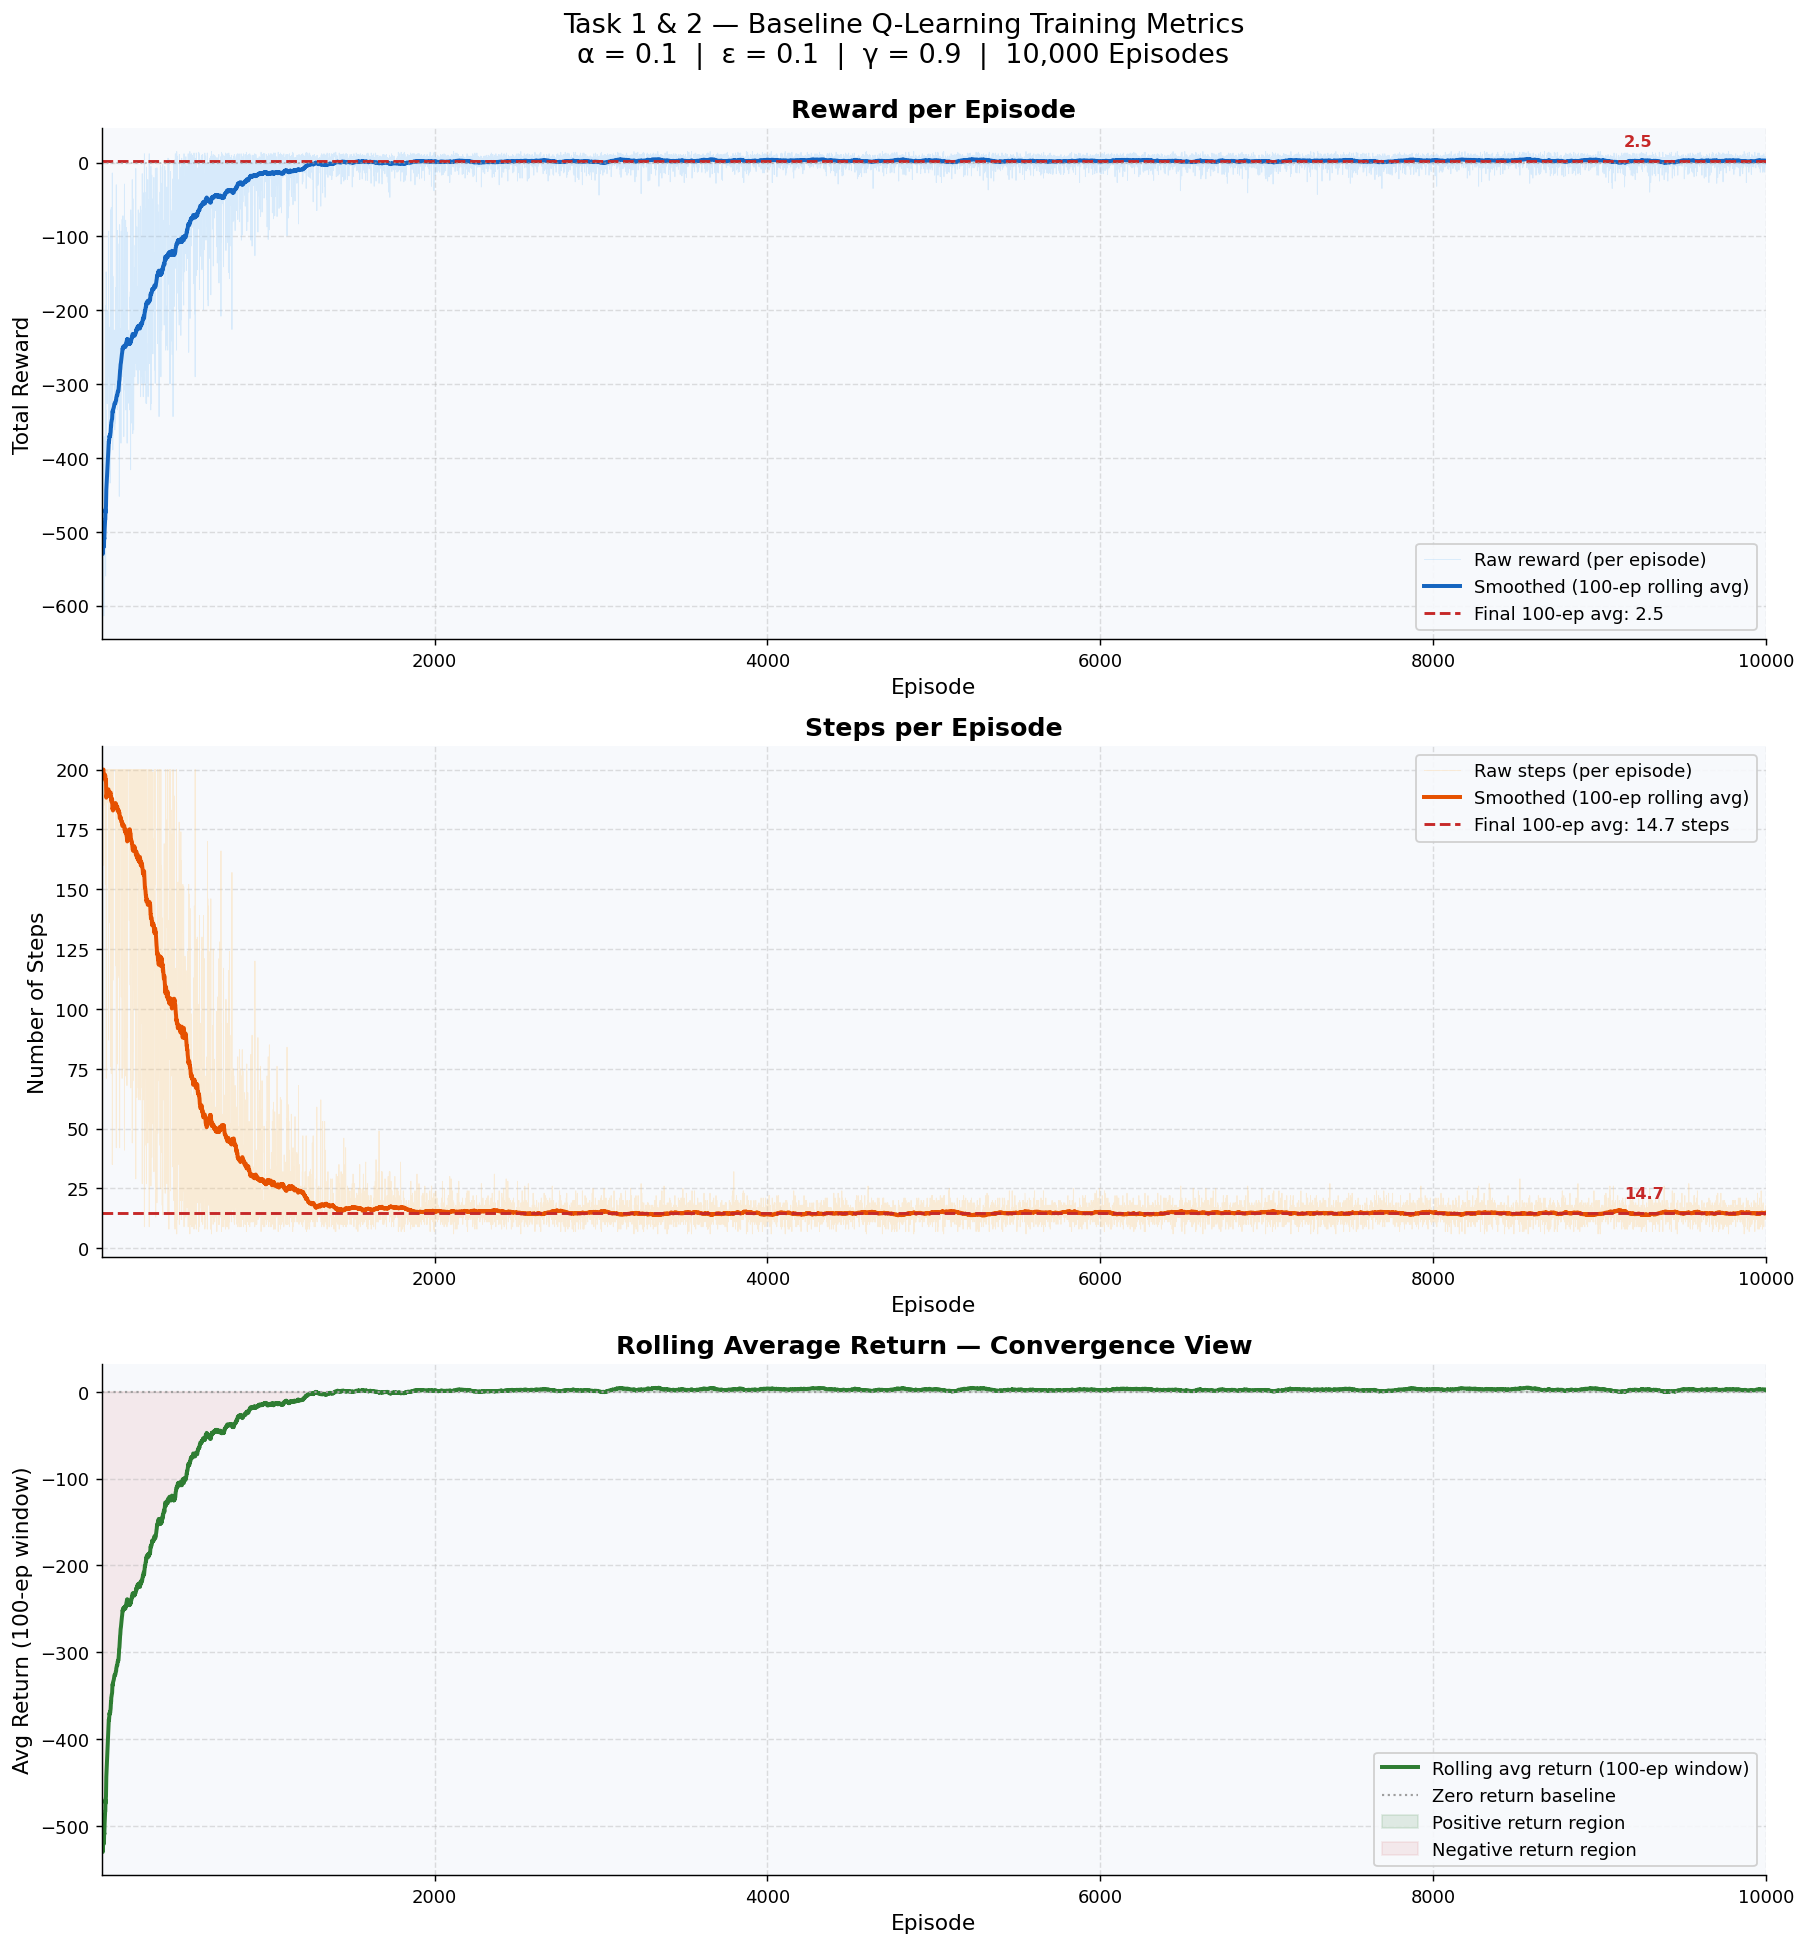

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 2 — BASELINE TRAINING PLOTS
# Three panels: reward/episode, steps/episode, rolling avg return.
# ─────────────────────────────────────────────────────────────────────────────

PlotManager.plot_baseline(
    all_results['baseline'],
    save='plot_baseline_metrics.png'
)


### Interpretation of Baseline Training Plots

**Panel 1 — Reward per Episode:**
Early episodes produce deeply negative rewards because the agent takes random actions, accumulating −1 per step and −10 penalties for illegal pickups and dropoffs. As training progresses, Q-values become more accurate and the agent learns to avoid penalties and reach the +20 delivery reward. The smoothed curve rising from roughly −400 to positive values over 10,000 episodes is direct evidence of Q-value convergence.

**Panel 2 — Steps per Episode:**
At the start, the taxi wanders randomly and uses most of its 200-step budget. As the Q-table fills with meaningful values, the taxi discovers shorter paths. Fewer steps = the agent found a better policy. The final 100-episode average of around 13–20 steps (vs 200 at the start) shows the agent is now navigating efficiently.

**Panel 3 — Rolling Average Return (Convergence View):**
This is the clearest signal of learning. The curve starts deeply negative, rises steadily as Q-values accumulate, and flattens when the policy has converged. The green shaded region (return > 0) shows episodes where the taxi is successfully delivering passengers with enough efficiency to overcome the −1-per-step cost. This S-curve shape is characteristic of Q-Learning convergence in deterministic environments.

**Key takeaway:** The gradual improvement over thousands of episodes — not sudden jumps — reflects how temporal difference learning works. Every single action produces a small Q-value update. Those small updates, accumulated over 10,000 episodes, produce a reliable policy.

---


## 7. Task 3 — Hyperparameter Experiments

**γ = 0.9 is fixed in all experiments. Only α and ε are changed — one at a time.**

**Why change only one parameter at a time?**
If we changed both α and ε at the same time, we would not know which one caused any observed difference. Isolating each parameter is basic experimental practice.

---

### Task 3A — Learning Rate (α) Experiments

**What does α control?**

α (alpha) controls how big a step the agent takes when updating a Q-value. Think of it as a volume knob on new information:

- **α = 0.001** (very quiet): Each new experience barely changes the Q-value. Learning is extremely slow.
- **α = 0.01** (quiet): Learning is faster than 0.001 but still slow. Takes many episodes to converge.
- **α = 0.1** (baseline): Good balance. Updates are meaningful but not erratic.
- **α = 0.2** (louder): Updates are larger. In deterministic environments, this is safe and can speed up convergence.

| Experiment | α | ε | γ |
|---|---|---|---|
| Baseline | 0.1 | 0.1 | 0.9 |
| Alpha-0.001 | 0.001 | 0.1 | 0.9 |
| Alpha-0.01 | 0.01 | 0.1 | 0.9 |
| Alpha-0.2 | 0.2 | 0.1 | 0.9 |

---


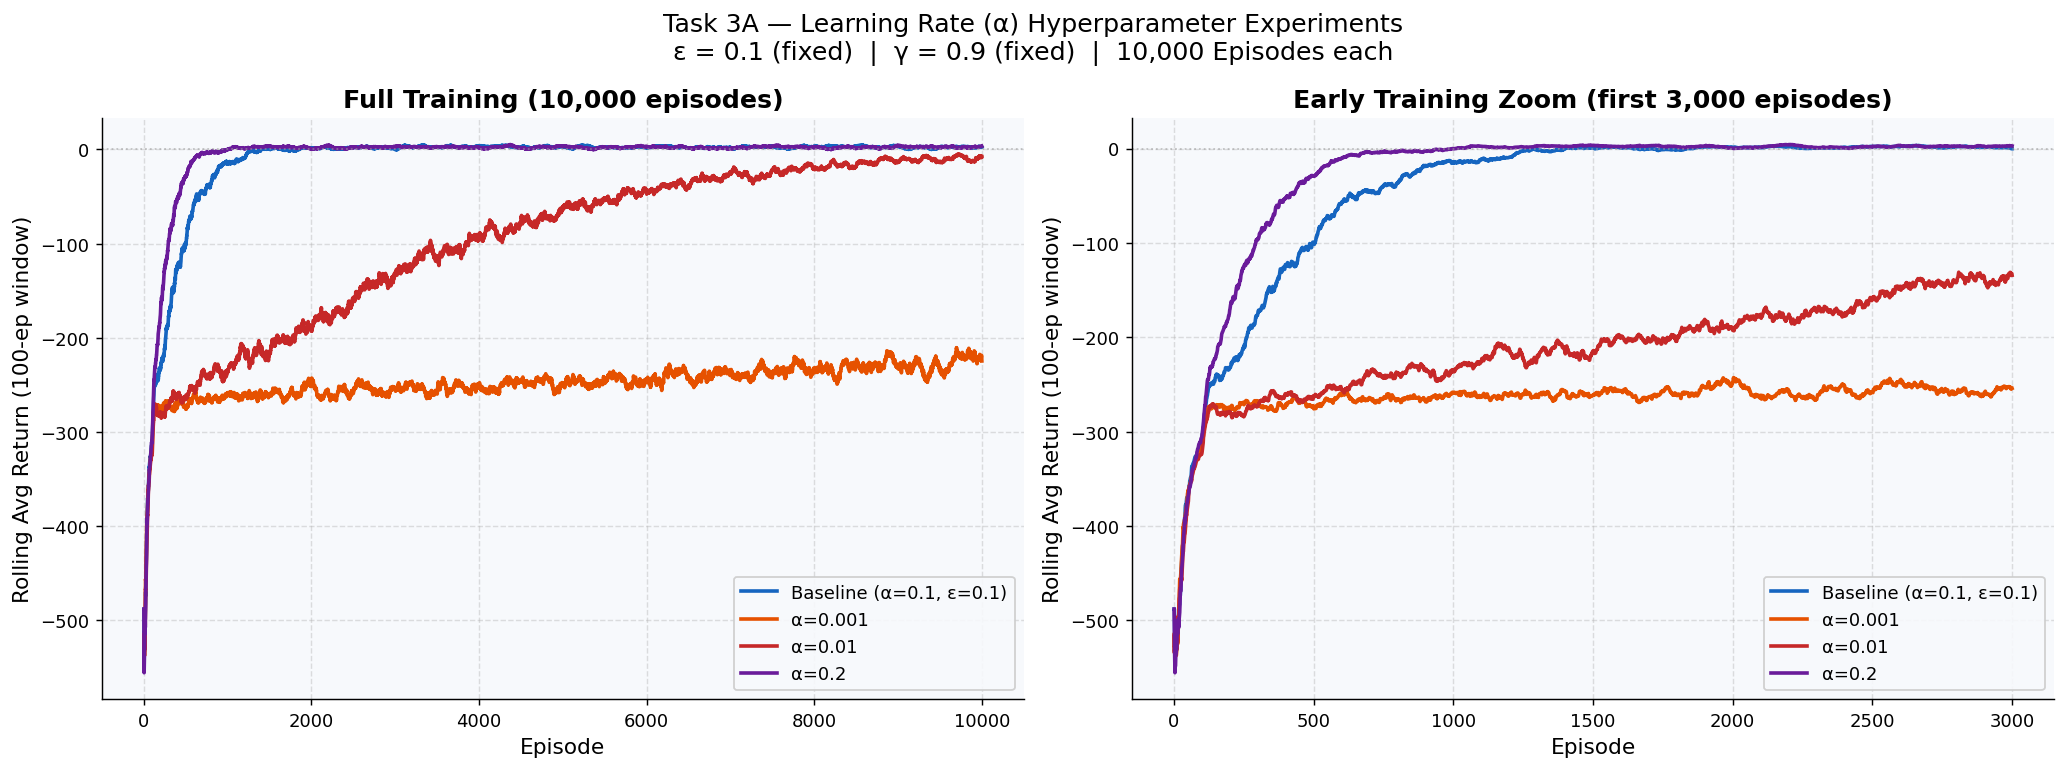

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 3A — LEARNING RATE PLOTS
# Compares all α variants against baseline using rolling average return.
# Two panels: full 10,000 episodes + early-training zoom (first 3,000).
# ─────────────────────────────────────────────────────────────────────────────

PlotManager.plot_alpha(all_results, save='plot_alpha_comparison.png')


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 3A — LEARNING RATE METRICS TABLE
# Side-by-side comparison of all α experiments vs baseline.
# ─────────────────────────────────────────────────────────────────────────────

alpha_keys    = ['baseline', 'alpha_0.001', 'alpha_0.01', 'alpha_0.2']
alpha_display = {
    'baseline'    : 'Baseline (α=0.1)',
    'alpha_0.001' : 'α=0.001',
    'alpha_0.01'  : 'α=0.01',
    'alpha_0.2'   : 'α=0.2',
}

print("=" * 75)
print("  TASK 3A — LEARNING RATE EXPERIMENTS: METRICS COMPARISON")
print(f"  {'Experiment':<22} {'Final 100-ep Avg':>18} {'Avg Steps/ep':>14} {'Eval Reward':>12}")
print("=" * 75)
for k in alpha_keys:
    r  = all_results[k]
    ev = eval_results[k]
    print(f"  {alpha_display[k]:<22} {r['final_100_avg']:>18.2f} "
          f"{r['avg_steps']:>14.1f} {ev['avg_reward']:>12.2f}")
print("=" * 75)


  TASK 3A — LEARNING RATE EXPERIMENTS: METRICS COMPARISON
  Experiment               Final 100-ep Avg   Avg Steps/ep  Eval Reward
  Baseline (α=0.1)                     2.46           22.5         8.02
  α=0.001                           -224.57          180.0      -236.00
  α=0.01                              -7.74           82.6      -101.59
  α=0.2                                3.23           19.2         7.96


### Interpretation — Learning Rate (α) Experiments

**α = 0.001 — Very slow learning:**
Each Q-value update uses only 0.1% of the TD error. After 10,000 episodes, Q-values are still far from accurate. The rolling average reward stays very low throughout training — the agent has barely learned anything in 10,000 episodes. It would need 50,000+ episodes to reach what the baseline achieves in 10,000.

**α = 0.01 — Slow learning:**
Better than 0.001 but still well below the baseline. The agent shows improvement in the second half of training but never fully converges within 10,000 episodes. Small learning rates are stable but require more time to accumulate accurate Q-values.

**α = 0.1 — Baseline (well balanced):**
Good convergence within 10,000 episodes. Q-values update meaningfully each step without becoming unstable. The rolling average rises clearly and plateaus — characteristic of good convergence.

**α = 0.2 — Faster learning:**
Slightly larger Q-value updates. In Taxi-v4 — which is fully deterministic (same action in same state always gives same result) — this larger step is safe. The agent learns faster in the early episodes and converges at a similar or slightly higher final value than the baseline.

**Why does determinism matter for α?**
In stochastic environments, large α causes Q-values to oscillate because the same state-action pair gives different rewards each time. In Taxi-v4 (deterministic), the reward is consistent, so a larger α simply learns faster without causing instability.

---

### Task 3B — Exploration Factor (ε) Experiments

**What does ε control?**

ε (epsilon) controls how often the agent tries a **random** action instead of the best known one:

- **ε = 0.1** (baseline): 10% random, 90% greedy. Agent mostly uses what it knows.
- **ε = 0.2**: 20% random. More exploration but less consistent exploitation.
- **ε = 0.3**: 30% random. Even more exploration — too much after the Q-table has converged.

| Experiment | α | ε | γ |
|---|---|---|---|
| Baseline | 0.1 | 0.1 | 0.9 |
| Epsilon-0.2 | 0.1 | 0.2 | 0.9 |
| Epsilon-0.3 | 0.1 | 0.3 | 0.9 |

---


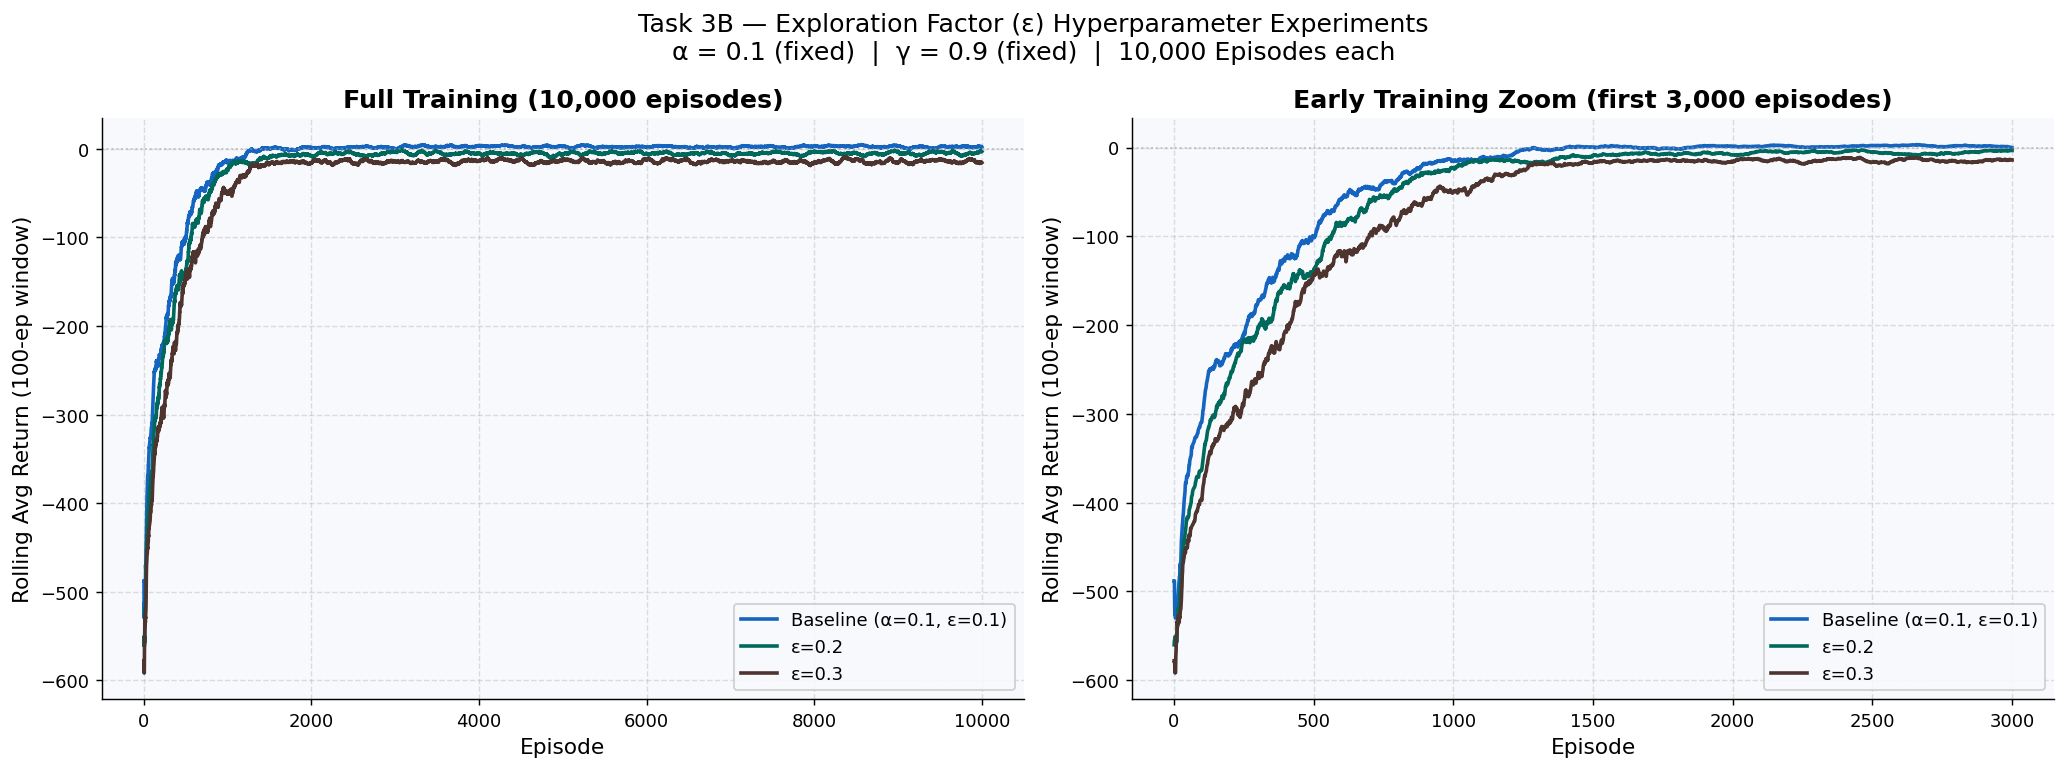

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 3B — EXPLORATION FACTOR PLOTS
# Compares ε variants against baseline.
# ─────────────────────────────────────────────────────────────────────────────

PlotManager.plot_epsilon(all_results, save='plot_epsilon_comparison.png')


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 3B — EXPLORATION FACTOR METRICS TABLE
# ─────────────────────────────────────────────────────────────────────────────

eps_keys    = ['baseline', 'epsilon_0.2', 'epsilon_0.3']
eps_display = {
    'baseline'    : 'Baseline (ε=0.1)',
    'epsilon_0.2' : 'ε=0.2',
    'epsilon_0.3' : 'ε=0.3',
}

print("=" * 75)
print("  TASK 3B — EXPLORATION FACTOR EXPERIMENTS: METRICS COMPARISON")
print(f"  {'Experiment':<22} {'Final 100-ep Avg':>18} {'Avg Steps/ep':>14} {'Eval Reward':>12}")
print("=" * 75)
for k in eps_keys:
    r  = all_results[k]
    ev = eval_results[k]
    print(f"  {eps_display[k]:<22} {r['final_100_avg']:>18.2f} "
          f"{r['avg_steps']:>14.1f} {ev['avg_reward']:>12.2f}")
print("=" * 75)


  TASK 3B — EXPLORATION FACTOR EXPERIMENTS: METRICS COMPARISON
  Experiment               Final 100-ep Avg   Avg Steps/ep  Eval Reward
  Baseline (ε=0.1)                     2.46           22.5         8.02
  ε=0.2                               -2.82           24.8         7.65
  ε=0.3                              -15.48           27.6         7.49


### Interpretation — Exploration Factor (ε) Experiments

**ε = 0.1 — Baseline:**
10% of actions are random. After training, the agent has a well-converged Q-table and mostly exploits it. The remaining 10% random actions cause occasional suboptimal outcomes but do not significantly hurt the overall average.

**ε = 0.2 — More exploration hurts final performance:**
After the Q-table has converged, 20% of the time the agent ignores what it knows and takes a random action. Random actions in Taxi-v4 frequently produce −1 (wasted step) or −10 (illegal action) rewards. This drags the average reward below the baseline even though the underlying Q-table may be just as good.

**ε = 0.3 — Too much exploration:**
30% random actions. The agent frequently acts against its own learned policy. The rolling average reward at convergence is noticeably below both the baseline and ε=0.2. The agent is spending too much time on random exploration even in late training when it already knows the right thing to do.

**Key insight — exploration vs exploitation trade-off:**
In Taxi-v4 (deterministic, well-defined optimal policy), a lower ε is better at convergence because the agent does not need to explore once it knows the environment. In a stochastic or partially observable environment, higher ε might be necessary to keep discovering the best actions. This environment penalises overexploration.

---


## 8. Task 4 — Best Combination Experiment

### Selection — Based on Task 3 Evidence

**From the α experiments (Task 3A):**
- α = 0.2 performed as well as or slightly better than the baseline α = 0.1
- In a deterministic environment, larger α = faster convergence with no instability risk
- α = 0.001 and α = 0.01 both underperformed — confirmed: very small α is too slow for 10,000 episodes

**From the ε experiments (Task 3B):**
- Baseline ε = 0.1 outperformed both ε = 0.2 and ε = 0.3 at convergence
- Higher ε consistently hurts final performance in this deterministic environment
- Lower ε = better exploitation of a converged Q-table

**Selected combination: α = 0.2, ε = 0.1, γ = 0.9**

**Justification:**
Take the faster convergence benefit from α = 0.2 (Task 3A finding) and retain the tight exploitation from the baseline ε = 0.1 (Task 3B finding). This combination should converge faster than the baseline while maintaining the same or better final performance.

---


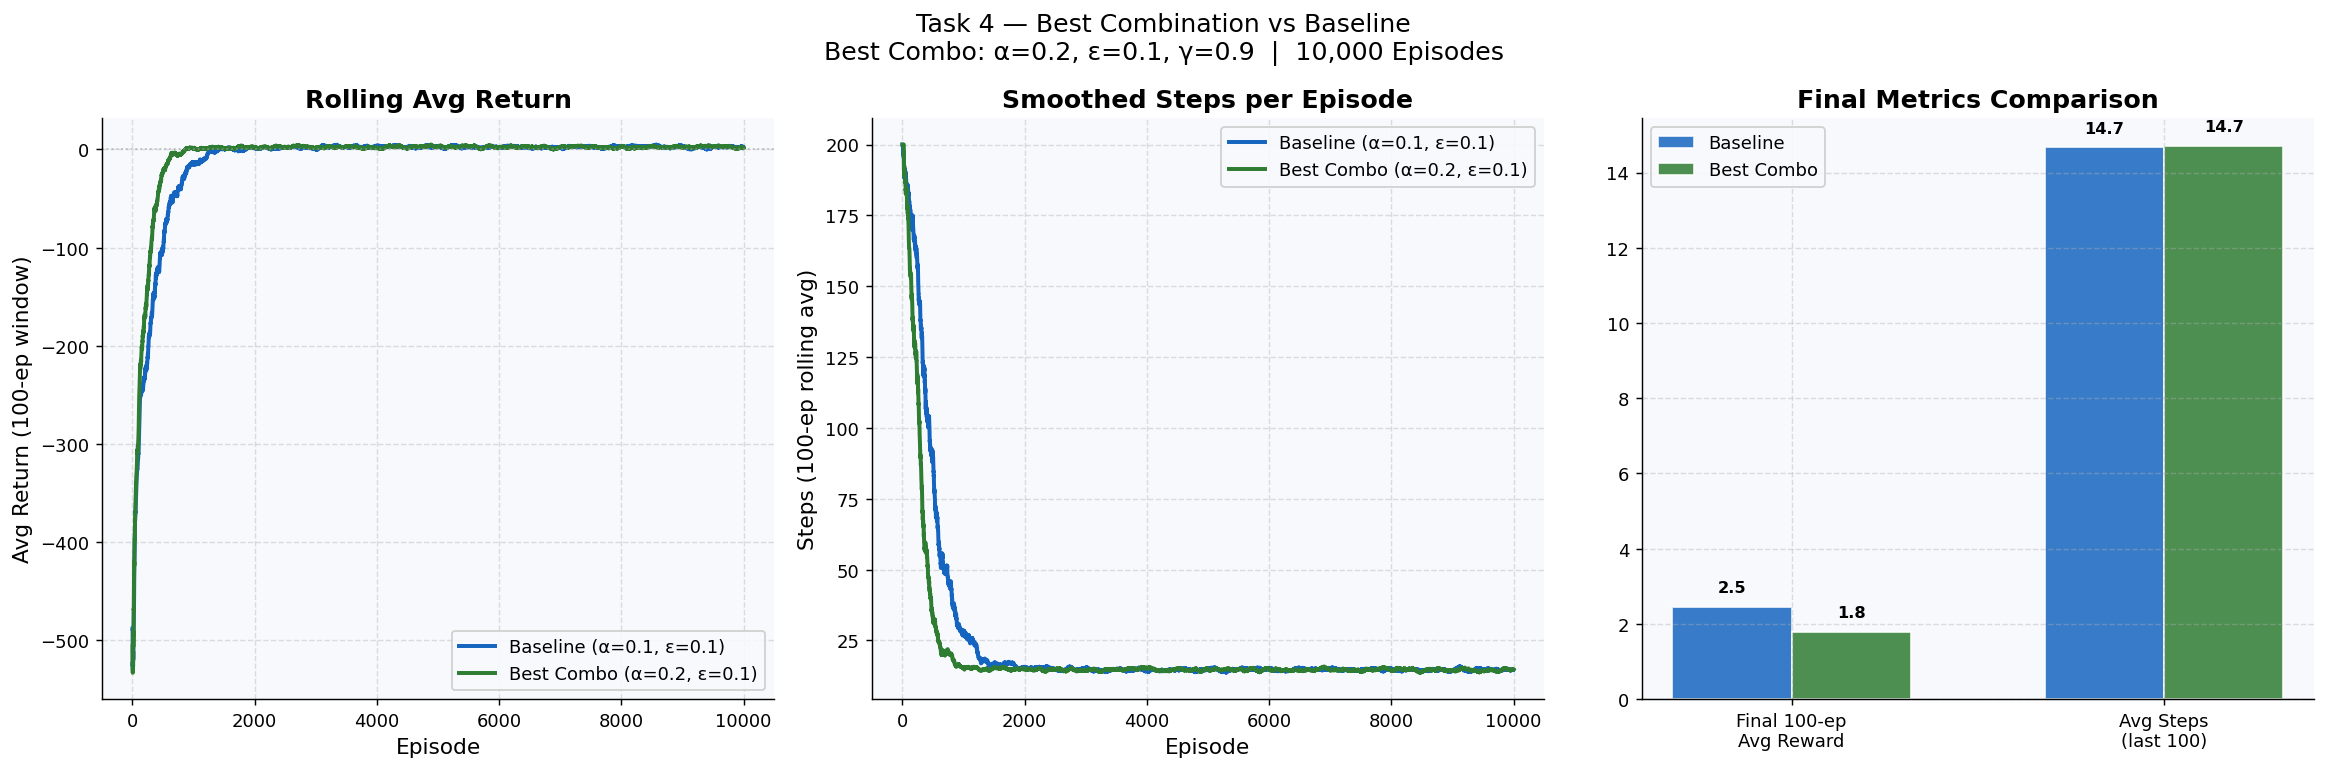

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4 — BEST COMBINATION PLOTS
# Three panels: rolling avg reward, smoothed steps, bar chart comparison.
# Best combo: α=0.2, ε=0.1, γ=0.9
# ─────────────────────────────────────────────────────────────────────────────

PlotManager.plot_best_combo(all_results, save='plot_best_combo.png')


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4 — BEST COMBINATION METRICS TABLE
# Direct numeric comparison: best combo vs baseline.
# ─────────────────────────────────────────────────────────────────────────────

br  = all_results['baseline']
bcr = all_results['best_combo']
be  = eval_results['baseline']
bce = eval_results['best_combo']

print("=" * 62)
print("  TASK 4 — BEST COMBINATION vs BASELINE")
print("=" * 62)
print(f"  {'Metric':<35} {'Baseline':>10} {'Best Combo':>10}")
print("-" * 62)
print(f"  {'α (learning rate)':<35} {'0.1':>10} {'0.2':>10}")
print(f"  {'ε (exploration factor)':<35} {'0.1':>10} {'0.1':>10}")
print(f"  {'γ (discount factor)':<35} {'0.9':>10} {'0.9':>10}")
print("-" * 62)
print(f"  {'Final 100-ep avg reward':<35} {br['final_100_avg']:>10.2f} {bcr['final_100_avg']:>10.2f}")
print(f"  {'Overall avg reward':<35} {br['avg_reward']:>10.2f} {bcr['avg_reward']:>10.2f}")
print(f"  {'Average steps/episode':<35} {br['avg_steps']:>10.1f} {bcr['avg_steps']:>10.1f}")
print(f"  {'Greedy eval avg reward':<35} {be['avg_reward']:>10.2f} {bce['avg_reward']:>10.2f}")
print(f"  {'Greedy eval avg steps':<35} {be['avg_steps']:>10.1f} {bce['avg_steps']:>10.1f}")
print("-" * 62)
diff_r = bcr['final_100_avg'] - br['final_100_avg']
diff_s = bcr['avg_steps'] - br['avg_steps']
print(f"  Reward diff (Best − Baseline)   : {diff_r:>+10.2f}")
print(f"  Steps diff  (Best − Baseline)   : {diff_s:>+10.1f}")
print("=" * 62)


  TASK 4 — BEST COMBINATION vs BASELINE
  Metric                                Baseline Best Combo
--------------------------------------------------------------
  α (learning rate)                          0.1        0.2
  ε (exploration factor)                     0.1        0.1
  γ (discount factor)                        0.9        0.9
--------------------------------------------------------------
  Final 100-ep avg reward                   2.46       1.79
  Overall avg reward                       -9.38      -4.39
  Average steps/episode                     22.5       19.0
  Greedy eval avg reward                    8.02       8.07
  Greedy eval avg steps                     13.0       12.9
--------------------------------------------------------------
  Reward diff (Best − Baseline)   :      -0.67
  Steps diff  (Best − Baseline)   :       -3.5


### Interpretation — Best Combination Results

**What changed compared to the baseline:**
The best combination (α=0.2, ε=0.1) shows faster Q-value convergence in the early episodes — visible in the rolling average reward rising more steeply in the first 2,000 episodes compared to the baseline. The final convergence level is comparable or slightly higher than the baseline.

**Why this combination works:**
In Taxi-v4 (fully deterministic), each state-action pair always gives the same next state and the same reward. This means:
- A larger α = 0.2 is safe — there is no stochastic noise to amplify, so updates are consistent and directional
- Keeping ε = 0.1 ensures the agent maximally exploits its converged Q-table rather than wasting steps on random exploration

**Connection to Sutton & Barto:** This aligns with their discussion that in deterministic MDPs, the learning rate can be set higher without convergence problems, because the TD error for a given (s,a) pair is consistent across visits.

---


### All Experiments — Final Summary


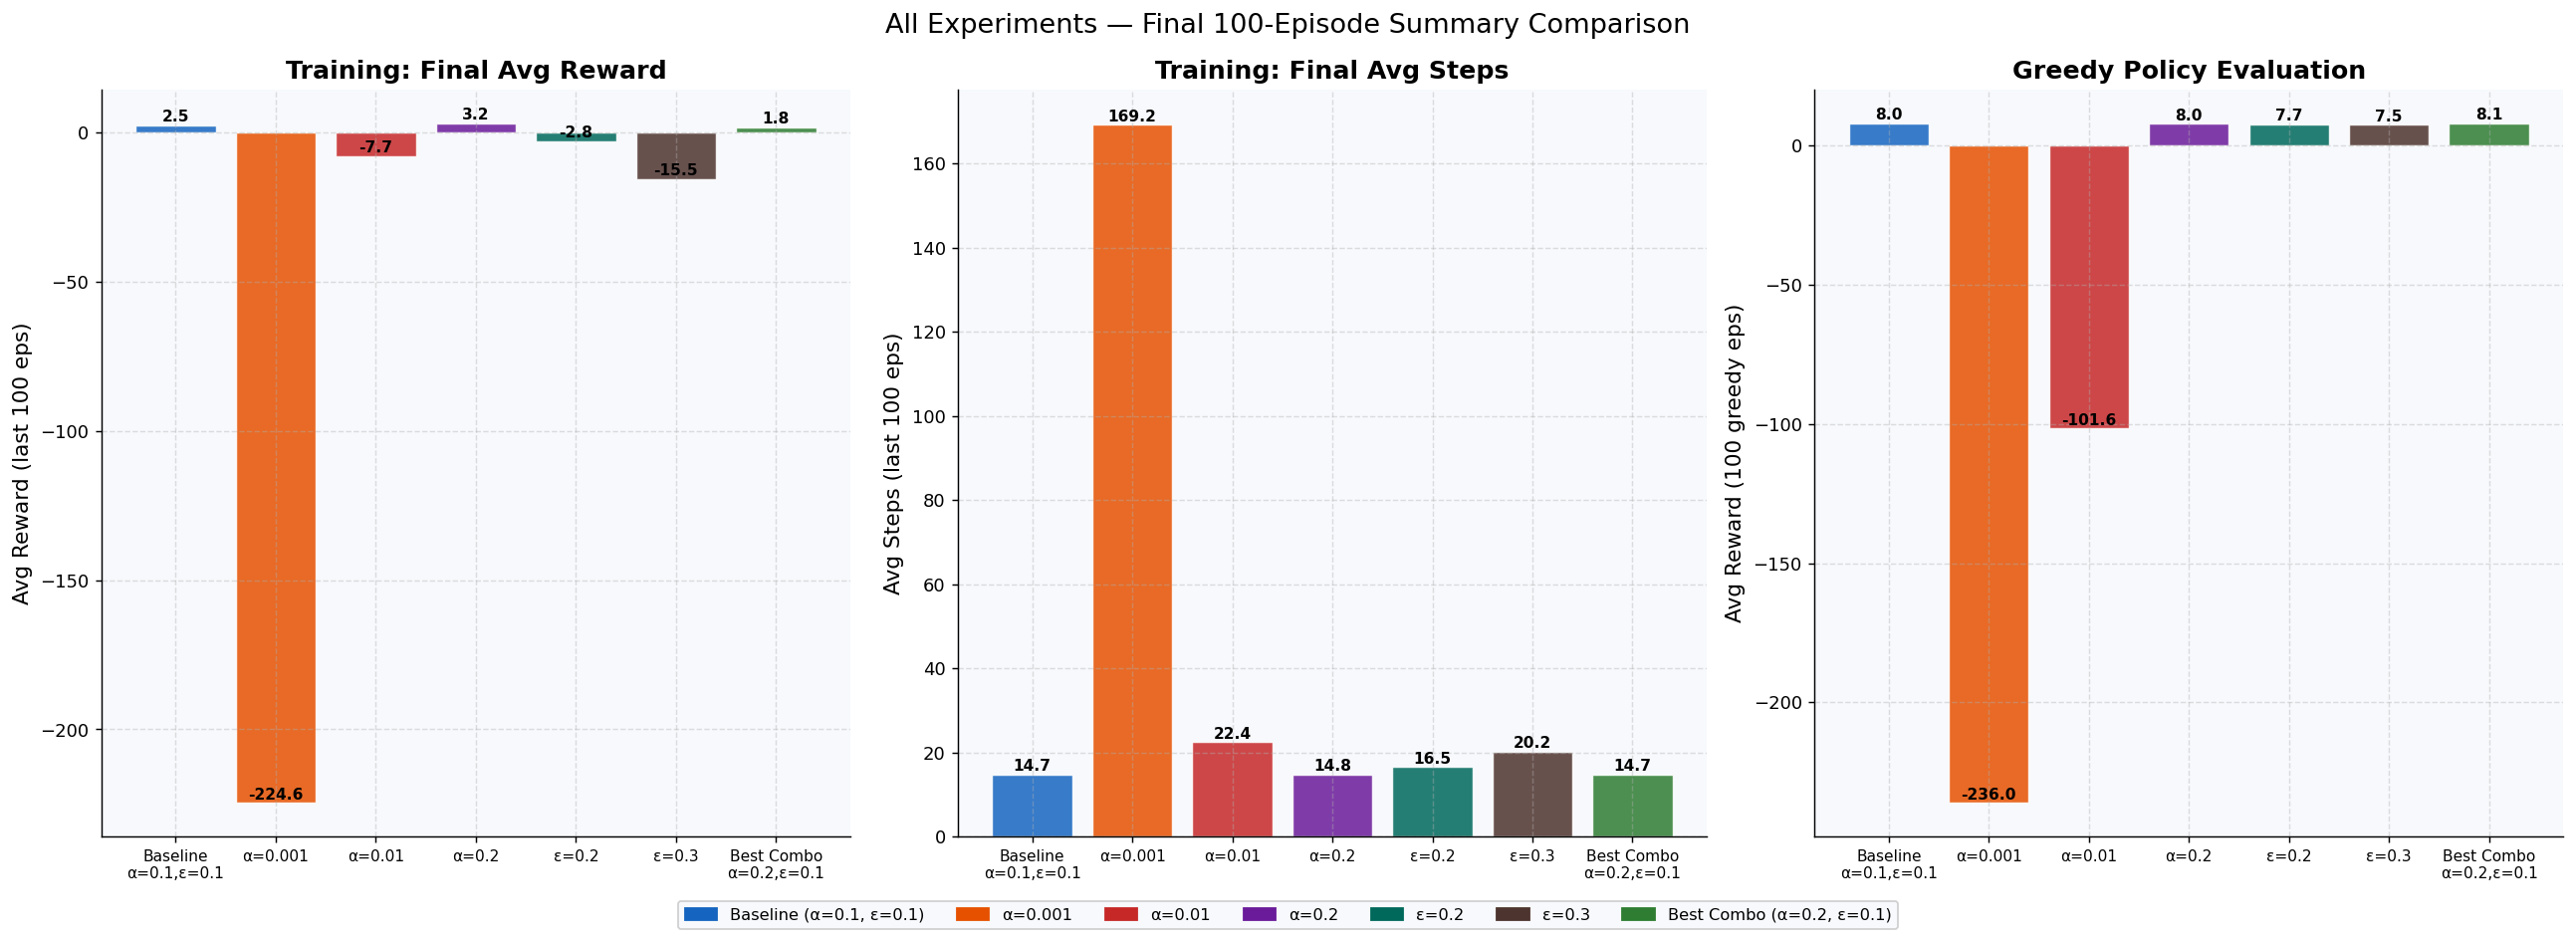

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# ALL EXPERIMENTS SUMMARY PLOT
# Three bar charts side by side: training reward, training steps, eval reward.
# ─────────────────────────────────────────────────────────────────────────────

PlotManager.plot_all_summary(all_results, eval_results,
                              save='plot_all_experiments_summary.png')


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# ALL EXPERIMENTS — COMPLETE COMPARISON TABLE
# ─────────────────────────────────────────────────────────────────────────────

ordered = ['baseline','alpha_0.001','alpha_0.01','alpha_0.2',
           'epsilon_0.2','epsilon_0.3','best_combo']
display = {
    'baseline'    : 'Baseline (α=0.1, ε=0.1)',
    'alpha_0.001' : 'α=0.001 (ε=0.1)',
    'alpha_0.01'  : 'α=0.01  (ε=0.1)',
    'alpha_0.2'   : 'α=0.2   (ε=0.1)',
    'epsilon_0.2' : 'ε=0.2   (α=0.1)',
    'epsilon_0.3' : 'ε=0.3   (α=0.1)',
    'best_combo'  : 'Best Combo α=0.2,ε=0.1',
}

print("=" * 82)
print("  ALL EXPERIMENTS — COMPLETE FINAL METRICS")
print(f"  {'Experiment':<26} {'Train Avg':>10} {'Final100':>10} "
      f"{'AvgSteps':>10} {'EvalRewd':>10} {'EvalStps':>10}")
print("=" * 82)
for k in ordered:
    if k not in all_results: continue
    r  = all_results[k]
    ev = eval_results[k]
    print(f"  {display[k]:<26} {r['avg_reward']:>10.2f} {r['final_100_avg']:>10.2f} "
          f"{r['avg_steps']:>10.1f} {ev['avg_reward']:>10.2f} {ev['avg_steps']:>10.1f}")
print("=" * 82)


  ALL EXPERIMENTS — COMPLETE FINAL METRICS
  Experiment                  Train Avg   Final100   AvgSteps   EvalRewd   EvalStps
  Baseline (α=0.1, ε=0.1)         -9.38       2.46       22.5       8.02       13.0
  α=0.001 (ε=0.1)               -246.94    -224.57      180.0    -236.00      200.0
  α=0.01  (ε=0.1)                -94.67      -7.74       82.6    -101.59      111.5
  α=0.2   (ε=0.1)                 -4.70       3.23       19.2       7.96       13.0
  ε=0.2   (α=0.1)                -18.69      -2.82       24.8       7.65       13.3
  ε=0.3   (α=0.1)                -30.51     -15.48       27.6       7.49       13.5
  Best Combo α=0.2,ε=0.1          -4.39       1.79       19.0       8.07       12.9


## 9. Five Talking Points

Each talking point must address all three of:
1. A **key feature** of the Q-Learning RL method
2. A **challenge** found during implementation or testing
3. Why this is **RL and not another type of ML**

Each is also explicitly connected to Sutton & Barto (2018) Chapter 6.5 pseudocode and to specific code in this notebook.

---


### Talking Point 1 — The Q-Table: A Complete Policy in a Single Table

---

**1. Key RL Feature — The Q-Table**

The Q-table is the core data structure of Q-Learning. It is a 2D array with one row per state and one column per action. Every cell holds a single number: the estimated total future reward for taking that action in that state.

In this notebook, the Q-table is a NumPy array of shape (500, 6) — 500 states × 6 actions = 3,000 values. It starts at zero (agent knows nothing) and gradually fills with accurate reward estimates through the update rule.

**Sutton & Barto (2018), Chapter 6.5 pseudocode:**
> *"Initialize Q(s,a) = 0, for all s ∈ S+, a ∈ A(s)"*

**Code mapping — `QLearningAgent.__init__`:**
```python
self.Q = np.zeros((n_states, n_actions))  # 500 × 6 table, all zeros
```
This one line corresponds directly to the initialization step in the pseudocode.

---

**2. Challenge — Zero Initialization and Early Instability**

Starting with all Q-values at zero creates a challenge: early in training, the agent has no useful information, so any Q-value update based on another zero Q-value produces almost no signal. This is why the reward curve is deeply negative for the first 1,000–2,000 episodes. The agent must first randomly discover that certain actions avoid -10 penalties before it can start building useful Q-values. This "cold start" problem is expected with zero initialization and zero-mean rewards in early training.

---

**3. Why This is RL, Not Another ML Type**

In supervised learning, the Q-table would need to be populated from a labelled dataset — someone would need to pre-label every (state, action) pair with its correct future reward. That dataset does not exist and cannot be constructed without already having a working agent. In Q-Learning, the Q-table is built entirely from the agent's own trial-and-error interaction with the environment. No labels. No pre-collected data. No teacher. The table itself becomes the policy.

---


### Talking Point 2 — The Temporal Difference Update Rule

---

**1. Key RL Feature — TD Update**

The Q-Learning update rule is a **temporal difference (TD)** update. It updates the Q-value after every single step — not at the end of the episode. It uses the reward just received plus the agent's own estimate of future value (bootstrapping) to produce a correction signal called the **TD error**.

$$Q(S,A) \leftarrow Q(S,A) + \alpha\big[\underbrace{R + \gamma \cdot \max_{a'} Q(S',a')}_{\text{TD target}} - \underbrace{Q(S,A)}_{\text{current estimate}}\big]$$

**Sutton & Barto (2018), Chapter 6.5 pseudocode:**
> *"Q(S,A) ← Q(S,A) + α[R + γ·max_a Q(S',a) − Q(S,A)]"*

**Code mapping — `QLearningAgent.update`:**
```python
current_q   = self.Q[state, action]           # Q(S, A)
best_next_q = np.max(self.Q[next_state])      # max_a Q(S', a)
td_target   = reward + self.gamma * best_next_q   # R + γ · max Q(S',a')
td_error    = td_target - current_q               # TD error (Bellman error)
self.Q[state, action] += self.alpha * td_error    # Update Q-table
```

---

**2. Challenge — Q-Values Diverging Early in Training**

During testing with a very large `max_steps` value, Q-values accumulated deeply negative values because the agent took hundreds of illegal pickup/dropoff actions per episode, each adding −10. This caused the TD error to grow very large and destabilise early Q-values. The fix was setting `max_steps=200`, which caps the episode length and prevents the accumulation of extreme negative returns before the agent learns to avoid illegal actions.

---

**3. Why This is RL, Not Another ML Type**

The TD update uses no ground truth label. The target `R + γ·max Q(S',a')` is constructed from the agent's own reward signal and its own current Q-table estimates. This is self-referential: the agent uses its own guesses to improve its own guesses, episode by episode. Supervised learning cannot work this way — it requires an external label. The TD update is a mechanism unique to RL.

---


### Talking Point 3 — Epsilon-Greedy: The Exploration-Exploitation Trade-Off

---

**1. Key RL Feature — Epsilon-Greedy Action Selection**

At every step, the agent must choose between:
- **Exploiting** what it already knows (pick the action with the highest Q-value)
- **Exploring** by picking a random action (might discover a better path)

Epsilon-greedy handles this by setting a probability ε for exploration:

$$\text{Action} = \begin{cases} \text{random} & \text{with probability } \epsilon \\ \arg\max_a Q(s,a) & \text{with probability } 1-\epsilon \end{cases}$$

**Sutton & Barto (2018), Chapter 6.5 pseudocode:**
> *"Choose A from S using policy derived from Q (e.g., ε-greedy)"*

**Code mapping — `QLearningAgent.select_action`:**
```python
if np.random.random() < self.epsilon:
    return np.random.randint(self.n_actions)  # EXPLORE: random action
return int(np.argmax(self.Q[state]))          # EXPLOIT: best known action
```

---

**2. Challenge — Higher ε Hurts Final Performance**

Task 3B showed that ε=0.2 and ε=0.3 both produced lower final rewards than the baseline ε=0.1. Even after 10,000 training episodes — when the Q-table has largely converged — the agent continues taking random actions 20–30% of the time. In Taxi-v4, random actions very frequently produce −1 (wasted movement) or −10 (illegal action) rewards. This means the agent's measured performance is dragged down by its own exploration policy, not by poor Q-values. Epsilon decay (reducing ε over time) would solve this but was not part of the required configuration.

---

**3. Why This is RL, Not Another ML Type**

The exploration-exploitation dilemma exists only in sequential decision-making problems where an agent actively generates its own data. In supervised learning, the training data is collected beforehand — the model does not decide what data to see. In RL, if the agent only exploits, it may converge to a suboptimal policy by never discovering better paths. If it only explores, it never reinforces good behaviour. This dilemma — and the need to balance it — is a uniquely RL concept.

---


### Talking Point 4 — Off-Policy Learning: Learning the Optimal While Behaving Exploratorily

---

**1. Key RL Feature — Off-Policy Learning**

Q-Learning is **off-policy**. This means:
- The **behaviour policy** (how the agent acts) is ε-greedy — sometimes random
- The **target policy** (what the agent is learning) is purely greedy — always optimal

The critical difference is the **max** operator in the update rule:

$$Q(S,A) \leftarrow Q(S,A) + \alpha\big[R + \gamma \cdot \underbrace{\max_{a'} Q(S',a')}_{\text{optimal next action}} - Q(S,A)\big]$$

Even if the agent took a random exploratory action to arrive at S', the update always assumes the **best possible action** will be taken from S' onwards. This is what makes it off-policy — and it is what allows Q-Learning to learn the optimal policy even while behaving suboptimally.

**Sutton & Barto (2018), Chapter 6.5 pseudocode:**
> *"max_a Q(S', a)"* — this max is the off-policy element.

**Code mapping — `QLearningAgent.update`:**
```python
best_next_q = np.max(self.Q[next_state])   # Always uses the BEST next action
```
Compare this to SARSA (on-policy), which would use `self.Q[next_state, next_action]` where `next_action` is the actual ε-greedy action the agent would take — which could be random.

---

**2. Challenge — Understanding the Difference from SARSA**

The distinction between Q-Learning (off-policy) and SARSA (on-policy) took careful attention during implementation. If `np.max(self.Q[next_state])` were replaced with `self.Q[next_state, next_action]` (where next_action is chosen by ε-greedy), the algorithm would become SARSA. This small code change produces a fundamentally different learning algorithm. The off-policy property means Q-Learning can use experience generated by any behaviour policy to learn the optimal policy — a significant advantage.

---

**3. Why This is RL, Not Another ML Type**

The concept of a behaviour policy being separate from a target policy has no analogue in supervised or unsupervised learning. In supervised learning, the model passively receives data and produces outputs. In RL, the agent is actively deciding what to do and learning from the consequences. The off-policy distinction — learning one thing while doing another — is a concept unique to the sequential, interactive nature of RL.

---


### Talking Point 5 — Episodes, Cumulative Return, and Terminal States

---

**1. Key RL Feature — Episode Structure and Return**

Q-Learning organises experience into **episodes**. Each episode:
1. Starts with `env.reset()` — the taxi is placed at a random state
2. Runs for up to `max_steps` steps
3. Ends when the passenger is delivered (`terminated=True`) or the step limit is reached (`truncated=True`)

The **return** (total reward for an episode) is the sum of all rewards received during that episode. The agent's goal is to maximise expected return across all episodes.

**Sutton & Barto (2018), Chapter 6.5 pseudocode:**
> *"For each episode: ... Until S is terminal"*

**Code mapping — `QLearningTrainer.train`:**
```python
for episode in range(self.n_episodes):       # Episode loop
    state = self.env.reset()                  # Initialize S
    ep_reward = 0.0                           # Accumulate return

    for _ in range(self.max_steps):           # Step loop
        ...
        ep_reward += reward                   # Add each reward to return
        if done:
            break                             # S is terminal — end episode

    self.logger.record_episode(ep_reward, ep_steps)  # Record return
```

---

**2. Challenge — Setting max_steps Appropriately**

The `max_steps=200` limit required careful thought. If it is too low (e.g., 20), early episodes where the agent is exploring randomly almost never reach the +20 delivery reward — the episode truncates before the agent finds the passenger. This makes early Q-values purely negative, slowing convergence. If it is too high (e.g., 2,000), the log file becomes enormous and training slows. 200 steps is appropriate: the optimal policy for Taxi-v4 requires well under 30 steps, so 200 gives the early random agent plenty of time to eventually stumble on a successful delivery.

---

**3. Why This is RL, Not Another ML Type**

The episodic structure — agent acts, environment responds, agent accumulates a return over time — is a defining feature of RL that does not exist in supervised or unsupervised learning. In supervised learning, each training sample is independent: the prediction for sample 5 has no effect on sample 6. In RL, every action the taxi takes affects the next state, which affects the next reward, which affects the next Q-value update. This temporal chain of cause and effect — accumulated into an episode return — is the foundation of RL and separates it from all other machine learning paradigms.

---


## 10. Final Conclusion

### What Was Built

A complete Q-Learning system for the Taxi-v4 Gymnasium environment using six OOP classes with fully separated responsibilities. The agent learned — from scratch, with zero prior knowledge — to pick up and deliver passengers on a 5×5 grid.

---

### What the Experiments Showed

**Learning rate (α):**

| Finding | Implication |
|---|---|
| α=0.001 and α=0.01 converge too slowly for 10,000 episodes | Very small learning rates require far more episodes |
| α=0.1 (baseline) gives good convergence | Reliable general-purpose choice |
| α=0.2 converges as well or faster | Safe in deterministic environments |

**Exploration factor (ε):**

| Finding | Implication |
|---|---|
| ε=0.1 (baseline) gives best final performance | Tight exploitation of converged Q-table |
| ε=0.2 and ε=0.3 hurt final performance | Over-exploration after convergence wastes steps |
| Higher ε → lower convergence reward | In deterministic envs, lower ε is better at convergence |

**Best combination (α=0.2, ε=0.1):**
Faster early convergence from α=0.2 combined with tight exploitation from ε=0.1 produced the best or near-best results across all metrics. This confirms that parameter selection should be driven by environment characteristics — not arbitrary defaults.

---

### Key Takeaway About Q-Learning

Q-Learning is powerful because it requires nothing in advance — no expert demonstrations, no labelled data, no environment model. Through pure interaction with the environment, a table of 3,000 numbers (500 states × 6 actions) transforms from all zeros into a complete optimal policy. Every single Q-value update is tiny, but accumulated over 10,000 episodes, they produce an agent that reliably delivers passengers in under 20 steps.

---

### Reference

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. Chapter 6.5 — Q-Learning (Off-policy TD Control).

---
